# Ejercicio 1 - Velocidades del viento

El pronostico de la velocidad del viento es fundamental, sobre todo por sus implicaciones en: seguridad en la aviación y la navegación, generación de energía eólica, agricultura, construcción, meteorología, recreación y deporte. Los datos suministrados, reportan diferentes mediciones que pueden explicar y permitir realizar la predicción de la velocidad del viento. En este capitulo, desarrollarenos el EDA y modelos de prediccion para la base de datos "**Velocidades de viento**". 

A continuacion, instalaremos las librerias quer seran utilizadas a lo largo del ejercicio.

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# EDA y ETL 

En esta sección se desarrollarán los procesos de Análisis Exploratorio de Datos (EDA) y Extracción, Transformación y Carga (ETL) sobre la base de datos de "Velocidades de viento", con el objetivo de comprender en profundidad la estructura de los datos y analizar la problemática planteada.

In [43]:
df = pd.read_csv('/Users/user/Desktop/Maestria 2025/Maestria Uninorte/Primer semestre 2025/Machine Learning/Parcial1ML/docs/data_treino_dv_df_2000_2010.csv')
df

,HORA (UTC),"VENTO, DIREï¿½ï¿½O HORARIA (gr) (ï¿½ (gr))","VENTO, VELOCIDADE HORARIA (m/s)",UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),UMIDADE REL. MIN. NA HORA ANT. (AUT) (%),TEMPERATURA Mï¿½XIMA NA HORA ANT. (AUT) (ï¿½C),TEMPERATURA Mï¿½NIMA NA HORA ANT. (AUT) (ï¿½C),"UMIDADE RELATIVA DO AR, HORARIA (%)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)","PRECIPITAï¿½ï¿½O TOTAL, HORï¿½RIO (mm)","VENTO, RAJADA MAXIMA (m/s)",PRESSï¿½O ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSï¿½O ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)
0,12:00,0.809017,1.8,69.0,60.0,22.6,20.7,61.0,888.2,0.0,3.8,888.2,887.7
1,13:00,0.965926,2.7,62.0,55.0,24.2,22.5,55.0,888.4,0.0,4.7,888.4,888.2
2,14:00,0.891007,2.0,56.0,50.0,25.5,24.3,51.0,888.1,0.0,4.9,888.4,888.1
3,15:00,0.848048,2.5,52.0,44.0,27.4,25.0,44.0,887.4,0.0,5.8,888.1,887.4
4,16:00,0.224951,2.4,50.0,43.0,27.1,25.5,46.0,886.5,0.0,5.8,887.4,886.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
87688,19:00,-0.615661,5.6,83.0,78.0,21.8,21.1,80.0,879.1,0.0,12.3,879.8,879.1
87689,20:00,-0.469472,4.9,84.0,79.0,21.7,21.0,84.0,879.2,0.0,9.9,879.2,878.9
87690,21:00,-0.484810,4.5,86.0,82.0,21.2,20.6,86.0,879.7,0.0,8.9,879.8,879.2
87691,22:00,-0.484810,3.2,88.0,85.0,20.6,20.2,88.0,880.5,0.0,8.0,880.5,879.6


Se observa un total de 87,693 muestras y 13 columnas, que contienen información relacionada con variables meteorológicas como humedad, presión, precipitación, temperatura y viento (incluyendo velocidad, dirección y ráfaga máxima). Además, se cuenta con una variable temporal registrada en formato horario militar.

Con el fin de facilitar el manejo y análisis de los datos, se procederá a reducir la longitud de los nombres de las variables, manteniendo su significado original pero mejorando la legibilidad y eficiencia en el procesamiento.

#### Renombramiento de columnas

A continuación se muestra la correspondencia entre los nombres originales del dataset y los nuevos nombres utilizados para facilitar el análisis:

| Nombre original                                                      | Nuevo nombre         |
|----------------------------------------------------------------------|----------------------|
| HORA (UTC)                                                           | `hora`               |
| VENTO, DIREÇÃO HORARIA (gr)                                          | `viento_dir`         |
| VENTO, VELOCIDADE HORARIA (m/s)                                      | `viento_vel`         |
| UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)                             | `humedad_max_ant`    |
| UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)                             | `humedad_min_ant`    |
| TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)                           | `temp_max_ant`       |
| TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)                           | `temp_min_ant`       |
| UMIDADE RELATIVA DO AR, HORARIA (%)                                  | `humedad_horaria`    |
| PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)               | `presion_horaria`    |
| PRECIPITAÇÃO TOTAL, HORÁRIA (mm)                                     | `precipitacion`      |
| VENTO, RAJADA MAXIMA (m/s)                                           | `viento_rafaga_max`  |
| PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)                      | `presion_max_ant`    |
| PRESSÃO ATMOSFERICA MIN.NA HORA ANT. (AUT) (mB)                      | `presion_min_ant`    |


In [44]:
# Renombramos los nombres de cada columna 
df.columns = [
    'hora',
    'viento_dir',
    'viento_vel',
    'humedad_max_ant',
    'humedad_min_ant',
    'temp_max_ant',
    'temp_min_ant',
    'humedad_horaria',
    'presion_horaria',
    'precipitacion',
    'viento_rafaga_max',
    'presion_max_ant',
    'presion_min_ant'
    ]

df.columns

Index(['hora', 'viento_dir', 'viento_vel', 'humedad_max_ant',
       'humedad_min_ant', 'temp_max_ant', 'temp_min_ant', 'humedad_horaria',
       'presion_horaria', 'precipitacion', 'viento_rafaga_max',
       'presion_max_ant', 'presion_min_ant'],
      dtype='object')

Una vez realizado el cambio de nombres de las variables, se dará inicio al análisis exploratorio para comprender mejor la base de datos e identificar posibles patrones o relaciones entre las variables.

#### Descripción de tipos de variables

En esta sección se llevará a cabo un análisis exploratorio de datos con el objetivo de comprender la estructura del conjunto de datos, identificar patrones, detectar posibles anomalías y seleccionar variables relevantes para el desarrollo de modelos predictivos.

In [45]:
var = [
    'hora',
    'viento_dir',
    'viento_vel',
    'humedad_max_ant',
    'humedad_min_ant',
    'temp_max_ant',
    'temp_min_ant',
    'humedad_horaria',
    'presion_horaria',
    'precipitacion',
    'viento_rafaga_max',
    'presion_max_ant',
    'presion_min_ant'
    ]

df[var].describe().T

,count,mean,std,min,25%,50%,75%,max
viento_dir,87693.0,0.405810,0.686247,-1.0,-0.156434,0.788011,0.970296,1.0
viento_vel,87693.0,2.466192,1.313968,0.0,1.500000,2.400000,3.400000,10.0
humedad_max_ant,87693.0,69.058465,19.640222,12.0,54.000000,72.000000,87.000000,100.0
humedad_min_ant,87693.0,63.176194,20.166336,10.0,48.000000,64.000000,80.000000,98.0
temp_max_ant,87693.0,21.921264,3.721386,9.2,19.200000,21.400000,24.700000,35.3
temp_min_ant,87693.0,20.684570,3.513744,8.4,18.400000,20.200000,23.100000,34.4
humedad_horaria,87693.0,66.146682,19.992327,10.0,51.000000,68.000000,84.000000,99.0
presion_horaria,87693.0,887.251925,4.012404,863.4,885.300000,887.200000,889.100000,1023.5
precipitacion,87693.0,0.160907,1.307515,0.0,0.000000,0.000000,0.000000,70.8
viento_rafaga_max,87693.0,5.161076,2.311157,0.0,3.400000,5.000000,6.800000,24.3


En la tabla anterior se presentan diversas estadísticas descriptivas de la base de datos, incluyendo la media, desviación estándar, valores mínimos y máximos, así como los cuartiles (25, 50 y 75%) y el conteo total de observaciones por variable.

Entre los valores destacados, se observa que la temperatura promedio se encuentra entre **20 °C** y **21 °C**, alcanzando un máximo de **35 °C**. Por otro lado, la velocidad del viento suele ser baja en general; sin embargo, se registró un valor máximo de **24.3 m/s** en las ráfagas máximas, lo cual podría representar un indicio del potencial aprovechamiento de este recurso energético en determinadas condiciones.

In [46]:
df.isnull().sum()

hora                 0
viento_dir           0
viento_vel           0
humedad_max_ant      0
humedad_min_ant      0
temp_max_ant         0
temp_min_ant         0
humedad_horaria      0
presion_horaria      0
precipitacion        0
viento_rafaga_max    0
presion_max_ant      0
presion_min_ant      0
dtype: int64

Al analizar la base de datos, observamos que no se presentan datos faltantes en ninguna de las variables utilizadas para el análisis. Esto implica que no es necesario aplicar técnicas de imputación ni eliminar registros, por lo que podemos trabajar con la totalidad de la información suministrada.

El objetivo principal de este proyecto es diseñar un modelo de regresión que permita comprender el comportamiento de la velocidad del viento a partir de las variables explicativas incluidas en el conjunto de datos. Para lograr este objetivo, es fundamental analizar la relación entre las variables independientes y la variable de respuesta.

En la siguiente sección se realizará un análisis exploratorio de los datos con el fin de identificar patrones, tendencias y posibles relaciones entre las variables que puedan contribuir al desempeño del modelo de predicción.

#### Analisis de correlacion entre variables explicativas y de respuesta

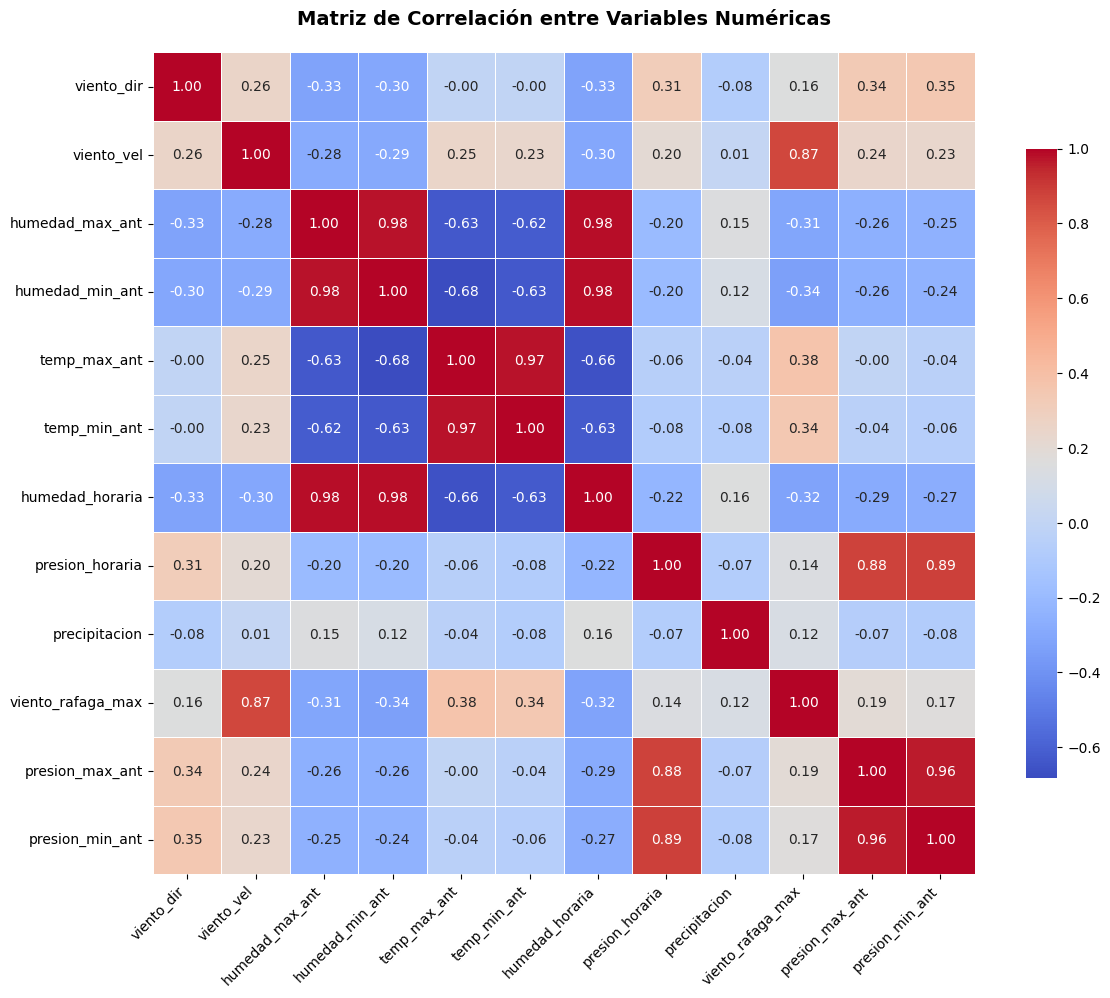

In [47]:
# Calcular la correlación
dfcor =  df.drop(columns=['hora'])

corr_matrix = dfcor.corr()

# Crear figura más grande
plt.figure(figsize=(12, 10))

# Dibujar heatmap
sns.heatmap(
    corr_matrix,
    annot=True,                 # Mostrar los valores
    fmt=".2f",                  # Formato de los números
    cmap='coolwarm',            # Mapa de color
    square=True,                # Cuadrícula cuadrada
    cbar_kws={"shrink": 0.75},  # Barra de color más pequeña
    linewidths=0.5,             # Líneas entre celdas
    annot_kws={"size": 10}      # Tamaño del texto de los valores
)

# Ajustes de etiquetas
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

# Título general
plt.title("Matriz de Correlación entre Variables Numéricas", fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

En la figura anterior, se presenta un mapa de calor que muestra el coeficiente de correlación entre las variables numéricas del conjunto de datos. A partir de esta visualización, podemos destacar que la mayoría de las variables presentan coeficientes de correlación relativamente bajos, oscilando entre 0 y 0.4.

Sin embargo, algunas variables muestran correlaciones superiores a 0.8. Este comportamiento se debe principalmente a que dichas variables fueron generadas a través de técnicas de **feature engineering**. Por ejemplo, a partir de variables generales como humedad, presión, temperatura y viento, se derivaron nuevas variables como máximos, mínimos, dirección del viento y ráfaga máxima. Estas derivaciones naturalmente comparten información con las variables originales, generando así una alta correlación entre ellas.

A continuación, observaremos el coeficiente de correlación de todas las variables con respecto a la variable objetivo: velocidad del viento, con el fin de identificar aquellas variables que podrían tener mayor influencia en el modelo de predicción.

In [48]:
dfcor.corr()['viento_vel'].sort_values(ascending=False)

viento_vel           1.000000
viento_rafaga_max    0.868279
viento_dir           0.256588
temp_max_ant         0.247706
presion_max_ant      0.242446
presion_min_ant      0.231584
temp_min_ant         0.231472
presion_horaria      0.204031
precipitacion        0.009466
humedad_max_ant     -0.282787
humedad_min_ant     -0.291752
humedad_horaria     -0.301358
Name: viento_vel, dtype: float64

Se evidencia una correlación significativa entre la variable de respuesta **"viento_vel"** y diversas variables independientes del conjunto de datos. Para este análisis, se seleccionarán las variables **"vel_rafaga_max"**, **"humedad_horaria"**, **"presion_max_ant"** y **"temp_max_ant"**, ya que presentan los niveles más altos de correlación con la variable objetivo.

Esta selección no solo se basa en la magnitud del coeficiente de correlación, sino también en la representatividad de estas variables dentro de sus respectivas categorías. Es decir, variables como presión, temperatura, humedad y viento cuentan con múltiples subcategorías que derivan de una misma fuente de medición. Estas fueron generadas previamente mediante técnicas de feature engineering a partir de datos básicos.

Por esta razón, las variables seleccionadas actúan como representantes de su grupo, y las altas correlaciones observadas entre subcategorías pueden explicarse por el hecho de provenir de una misma categoría física o métrica.

En la siguiente sección, analizaremos el comportamiento de la variable objetivo respecto a estas variables seleccionadas, con el fin de explorar patrones y relaciones útiles para el desarrollo del modelo de regresión.

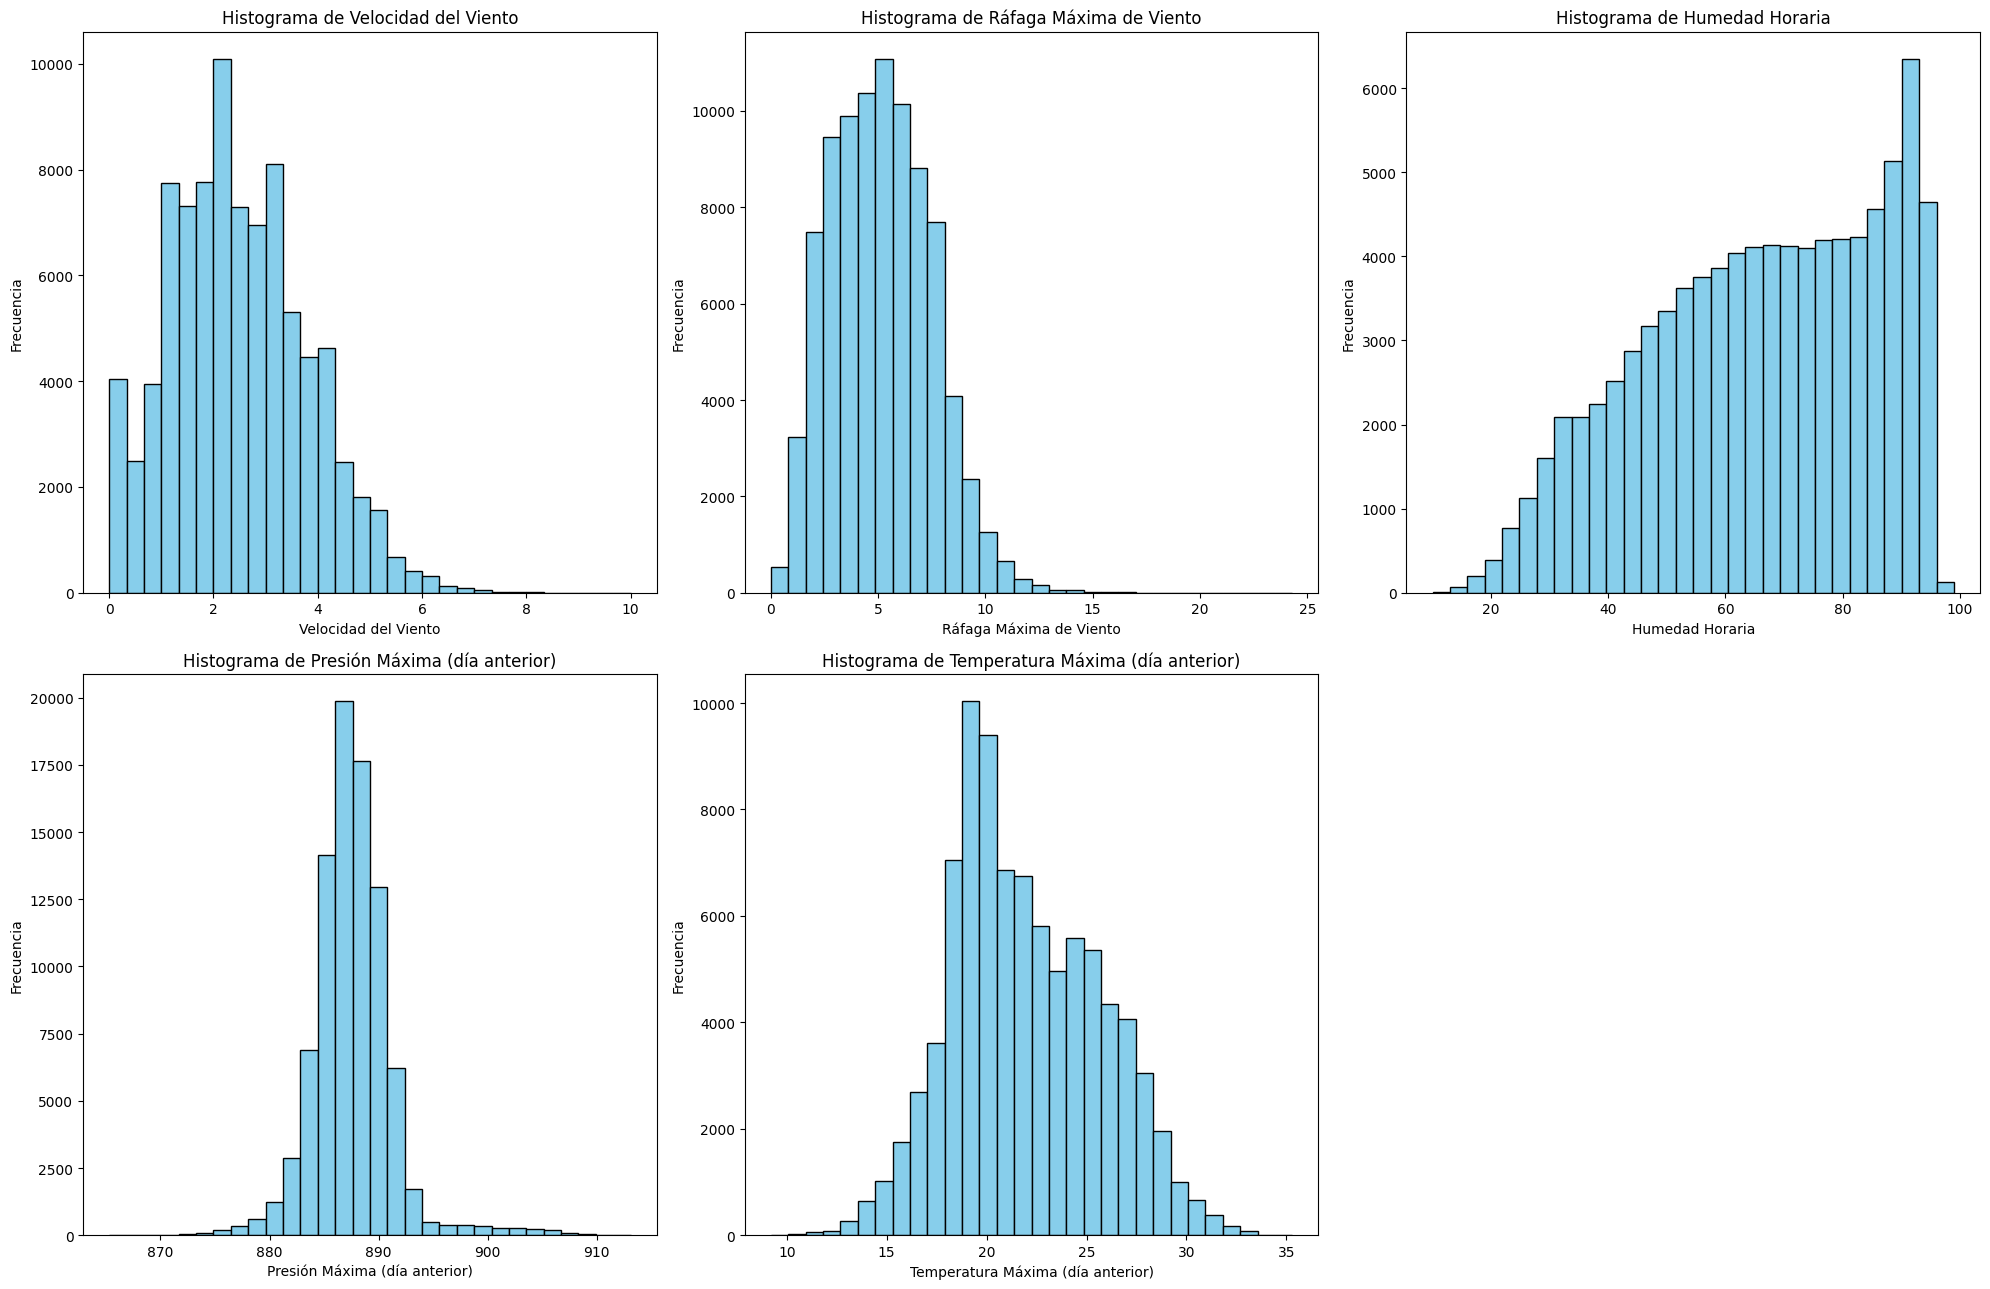

In [49]:
# Variables a graficar
variables = ['viento_vel', 'viento_rafaga_max', 'humedad_horaria', 'presion_max_ant', 'temp_max_ant']
titulos = [
    'Velocidad del Viento',
    'Ráfaga Máxima de Viento',
    'Humedad Horaria',
    'Presión Máxima (día anterior)',
    'Temperatura Máxima (día anterior)'
]

# Crear figura con subplots (2 filas, 3 columnas)
fig, axes = plt.subplots(2, 3, figsize=(20, 13))  # Tamaño ajustado

# Aplanamos los ejes para facilitar el indexado
axes = axes.flatten()

# Graficar cada variable
for i, var in enumerate(variables):
    axes[i].hist(df[var], bins=30, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Histograma de {titulos[i]}')
    axes[i].set_xlabel(titulos[i])
    axes[i].set_ylabel('Frecuencia')

# Eliminar el subplot vacío (último en posición 6 si solo usamos 5)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

En la figura anterior se observa la distribución de frecuencia de las variables explicativas y la variable de respuesta. Se puede apreciar que variables como presión máxima, temperatura máxima, ráfaga máxima y velocidad del viento tienden a presentar una forma similar a una distribución normal.

En particular, la ráfaga máxima y la velocidad del viento muestran un sesgo hacia la derecha, lo cual indica una mayor concentración de valores bajos con una cola extendida hacia valores altos. En contraste, la temperatura máxima y la presión máxima presentan distribuciones más centradas y simétricas.

No obstante, la distribución de presión máxima es más estrecha y picuda, lo que sugiere una forma leptocúrtica, mientras que la distribución de temperatura máxima es más suave y se aproxima a una forma mesocúrtica.

Para caracterizar de manera más precisa la simetría y forma de estas distribuciones, se calcularán los coeficientes de asimetría (skewness) y curtosis, lo que permitirá un análisis más riguroso de su comportamiento estadístico.

#### Analisis de simetria y datos atipicos 

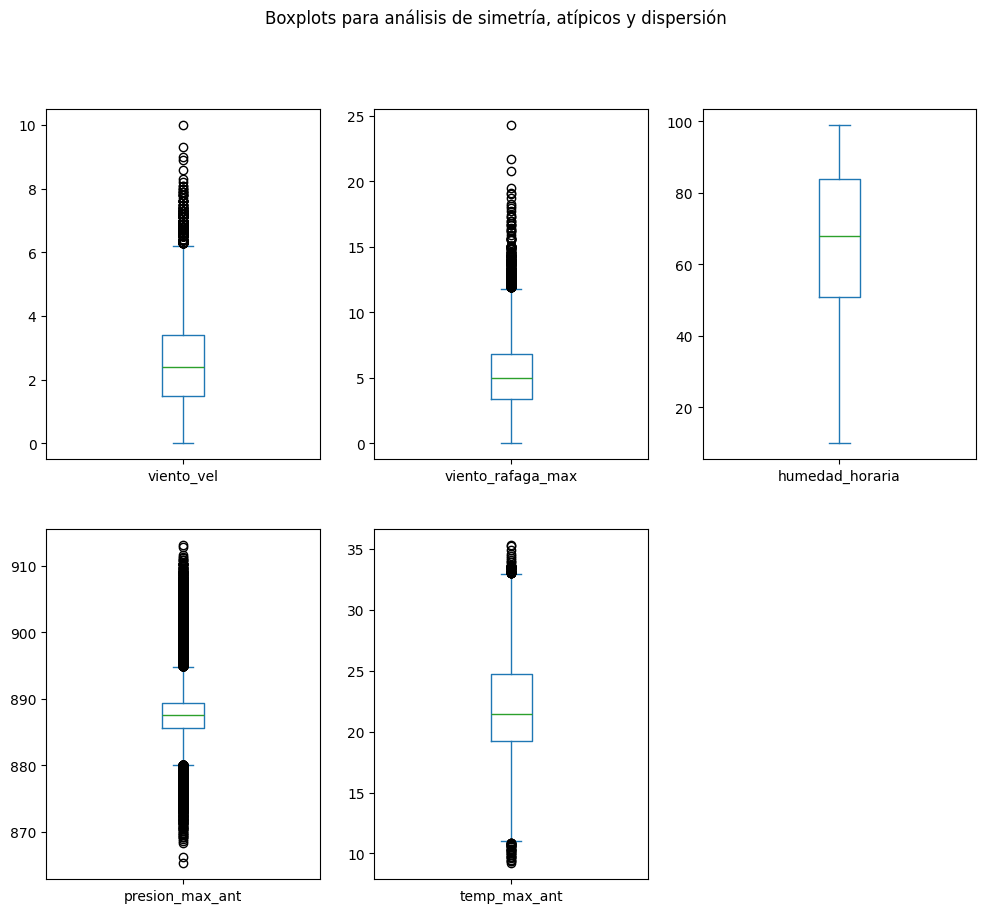

In [50]:
df[variables].plot(kind='box', subplots=True, layout=(2, 3), figsize=(12, 10), sharex=False)
plt.suptitle('Boxplots para análisis de simetría, atípicos y dispersión')
plt.show()

En la figura anterior, se presentan los boxplots de las variables previamente analizadas. En estas gráficas, se observa que las variables relacionadas con el viento (velocidad y ráfaga máxima) muestran la presencia de datos atípicos (outliers) por encima de los límites superiores, aunque sus medianas se encuentran centradas, lo que indica una distribución relativamente equilibrada en su núcleo.

En el caso de la presión máxima, la caja del boxplot es estrecha, lo que sugiere una baja dispersión: la mayoría de los valores se concentran alrededor de un rango específico. La temperatura máxima presenta un comportamiento similar, aunque en este caso se observan outliers tanto por encima como por debajo de los límites del rango intercuartílico, lo cual indica mayor variabilidad en los extremos.

Por otro lado, la variable humedad horaria no presenta valores atípicos visibles, pero muestra un rango intercuartílico más amplio, lo cual revela una mayor variabilidad en su distribución en comparación con las demás variables.

Estos boxplots permiten corroborar las observaciones realizadas previamente a partir de los histogramas, validando así las características básicas de la distribución de cada variable.

A continuación, para tener una mejor comprensión de la simetría y forma de las distribuciones, se realizará un análisis de asimetría (skewness) y curtosis (kurtosis), lo que permitirá evaluar si las variables presentan sesgo (asimetría) o colas pesadas (curtosis) en su distribución.

In [51]:
df[variables].skew()

viento_vel           0.370276
viento_rafaga_max    0.411720
humedad_horaria     -0.349514
presion_max_ant      1.024888
temp_max_ant         0.263013
dtype: float64

En el análisis de skewness de las variables meteorológicas, se observa que la mayoría presentan distribuciones ligeramente asimétricas, cercanas a la normalidad. Las variables viento_vel, viento_rafaga_max y temp_max_ant muestran una asimetría positiva leve, lo cual indica que sus distribuciones tienen una ligera cola hacia valores más altos, pero en general no requieren transformaciones.

Por otro lado, la variable humedad_horaria presenta una asimetría negativa ligera, lo que sugiere que hay una mayor concentración de valores altos (es decir, alta humedad), con una cola hacia valores bajos. Esta también se considera aceptablemente simétrica para la mayoría de los modelos.

Sin embargo, la variable presion_max_ant muestra una asimetría positiva más marcada (skewness > 1), lo que indica una distribución más sesgada hacia la derecha.


In [52]:
from scipy.stats import kurtosis

df[variables].kurtosis()

viento_vel          -0.105828
viento_rafaga_max    0.113629
humedad_horaria     -0.890021
presion_max_ant      5.819274
temp_max_ant        -0.417240
dtype: float64

El análisis de curtosis revela que la mayoría de las variables meteorológicas presentan distribuciones cercanas a lo normal. Por ejemplo, viento_vel y viento_rafaga_max tienen valores de curtosis muy próximos a cero, lo que indica que sus distribuciones son mesocúrticas, es decir, similares a una distribución normal, sin una presencia destacada de valores extremos ni colas inusuales. Del mismo modo, temp_max_ant muestra una ligera curtosis negativa, lo que sugiere una distribución algo más aplanada (platicúrtica), pero que no representa una preocupación significativa.

Por otro lado, humedad_horaria también presenta curtosis negativa más pronunciada, lo cual indica una distribución aún más aplanada, con menor frecuencia de valores extremos. Esta condición no suele ser problemática, pero puede implicar menor variabilidad en los valores fuera del promedio.

Sin embargo, la variable presion_max_ant destaca notablemente con una curtosis de 5.82, lo que la clasifica como leptocúrtica. Esto indica una alta concentración de datos alrededor de la media, pero también la presencia de colas pesadas, es decir, una mayor cantidad de valores extremos. 

A continuación, realizaremos un análisis bivariado para encontrar relaciones entre variables tanto entre la independiente (y) como las independientes (X).

In [53]:
from scipy.stats import kstest, zscore

# Especificar columnas a excluir
columnas_excluir = ['hora', 'viento_vel']

# Filtrar columnas numéricas para la prueba
columnas_ks = [col for col in df.columns if col not in columnas_excluir]

# Diccionario para guardar resultados
ks_results = {}

# Aplicar la prueba de Kolmogorov-Smirnov
for col in columnas_ks:
    try:
        # Convertir valores a numérico y eliminar nulos
        serie = pd.to_numeric(df[col], errors='coerce').dropna()
        
        # Normalizar (estandarizar) la serie
        serie_normalizada = zscore(serie)
        
        # Aplicar prueba KS comparando con distribución normal estándar
        stat, p_value = kstest(serie_normalizada, 'norm')
        
        # Guardar resultados
        ks_results[col] = {'KS Statistic': stat, 'p-value': p_value}
    except Exception as e:
        ks_results[col] = {'error': str(e)}

# Mostrar resultados
for col, resultado in ks_results.items():
    print(f"{col} → KS: {resultado.get('KS Statistic')}, p-value: {resultado.get('p-value')}")

viento_dir → KS: 0.21540831884600303, p-value: 0.0
humedad_max_ant → KS: 0.08634264138840075, p-value: 0.0
humedad_min_ant → KS: 0.0643174922561659, p-value: 7.9586675e-316
temp_max_ant → KS: 0.06696964630114338, p-value: 0.0
temp_min_ant → KS: 0.06277629820113922, p-value: 7.044432818342984e-301
humedad_horaria → KS: 0.07390455307154764, p-value: 0.0
presion_horaria → KS: 0.09381899422838846, p-value: 0.0
precipitacion → KS: 0.4791713558905091, p-value: 0.0
viento_rafaga_max → KS: 0.04162047824931375, p-value: 1.9648894696136483e-132
presion_max_ant → KS: 0.07661951069140971, p-value: 0.0
presion_min_ant → KS: 0.060524247741483794, p-value: 1.0836254040560572e-279


La prueba de Kolmogorov-Smirnov realizada sobre las variables indica que en todos los casos se rechaza la hipótesis nula de que siguen la distribución de referencia, dado que los valores de p son prácticamente cero. Esto evidencia diferencias estadísticamente significativas en todas las variables analizadas.

El estadístico KS muestra que "precipitacion" (0.479) y "viento_dir" (0.215) son las variables que más se desvían de la distribución esperada. El resto de las variables presenta diferencias más moderadas, con valores de KS entre aproximadamente 0.04 y 0.09, aunque igualmente significativas.

En síntesis, los resultados sugieren que ninguna de las variables sigue la distribución teórica asumida, por lo que sería recomendable utilizar métodos que no dependan de supuestos de normalidad o considerar transformaciones de las variables como escalamiento (Standardscaler).

#### Análisis bivariado

<Axes: title={'center': 'Velocidad promedio del viento por hora'}, xlabel='hora'>

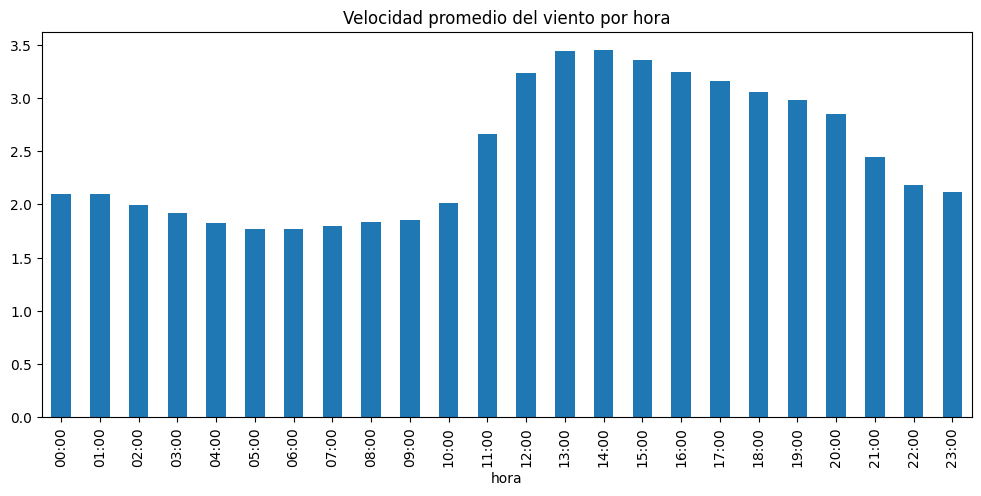

In [54]:
df.groupby('hora')['viento_vel'].mean().sort_index().plot(kind='bar', figsize=(12, 5), title='Velocidad promedio del viento por hora')

En la figura anterior, podemos observar la distribución de la velocidad media del viento (variable de respuesta, eje Y) en función de la hora. En la gráfica se observa que, en promedio, se presentan mayores velocidades entre las 11:00 y las 23:00 que entre las 00:00 y las 10:00. Adicionalmente, observamos que los puntos con menores velocidades se encuentran entre las 05:00 y las 08:00, lo que puede ser una muestra clara de la tendencia de la velocidad. 

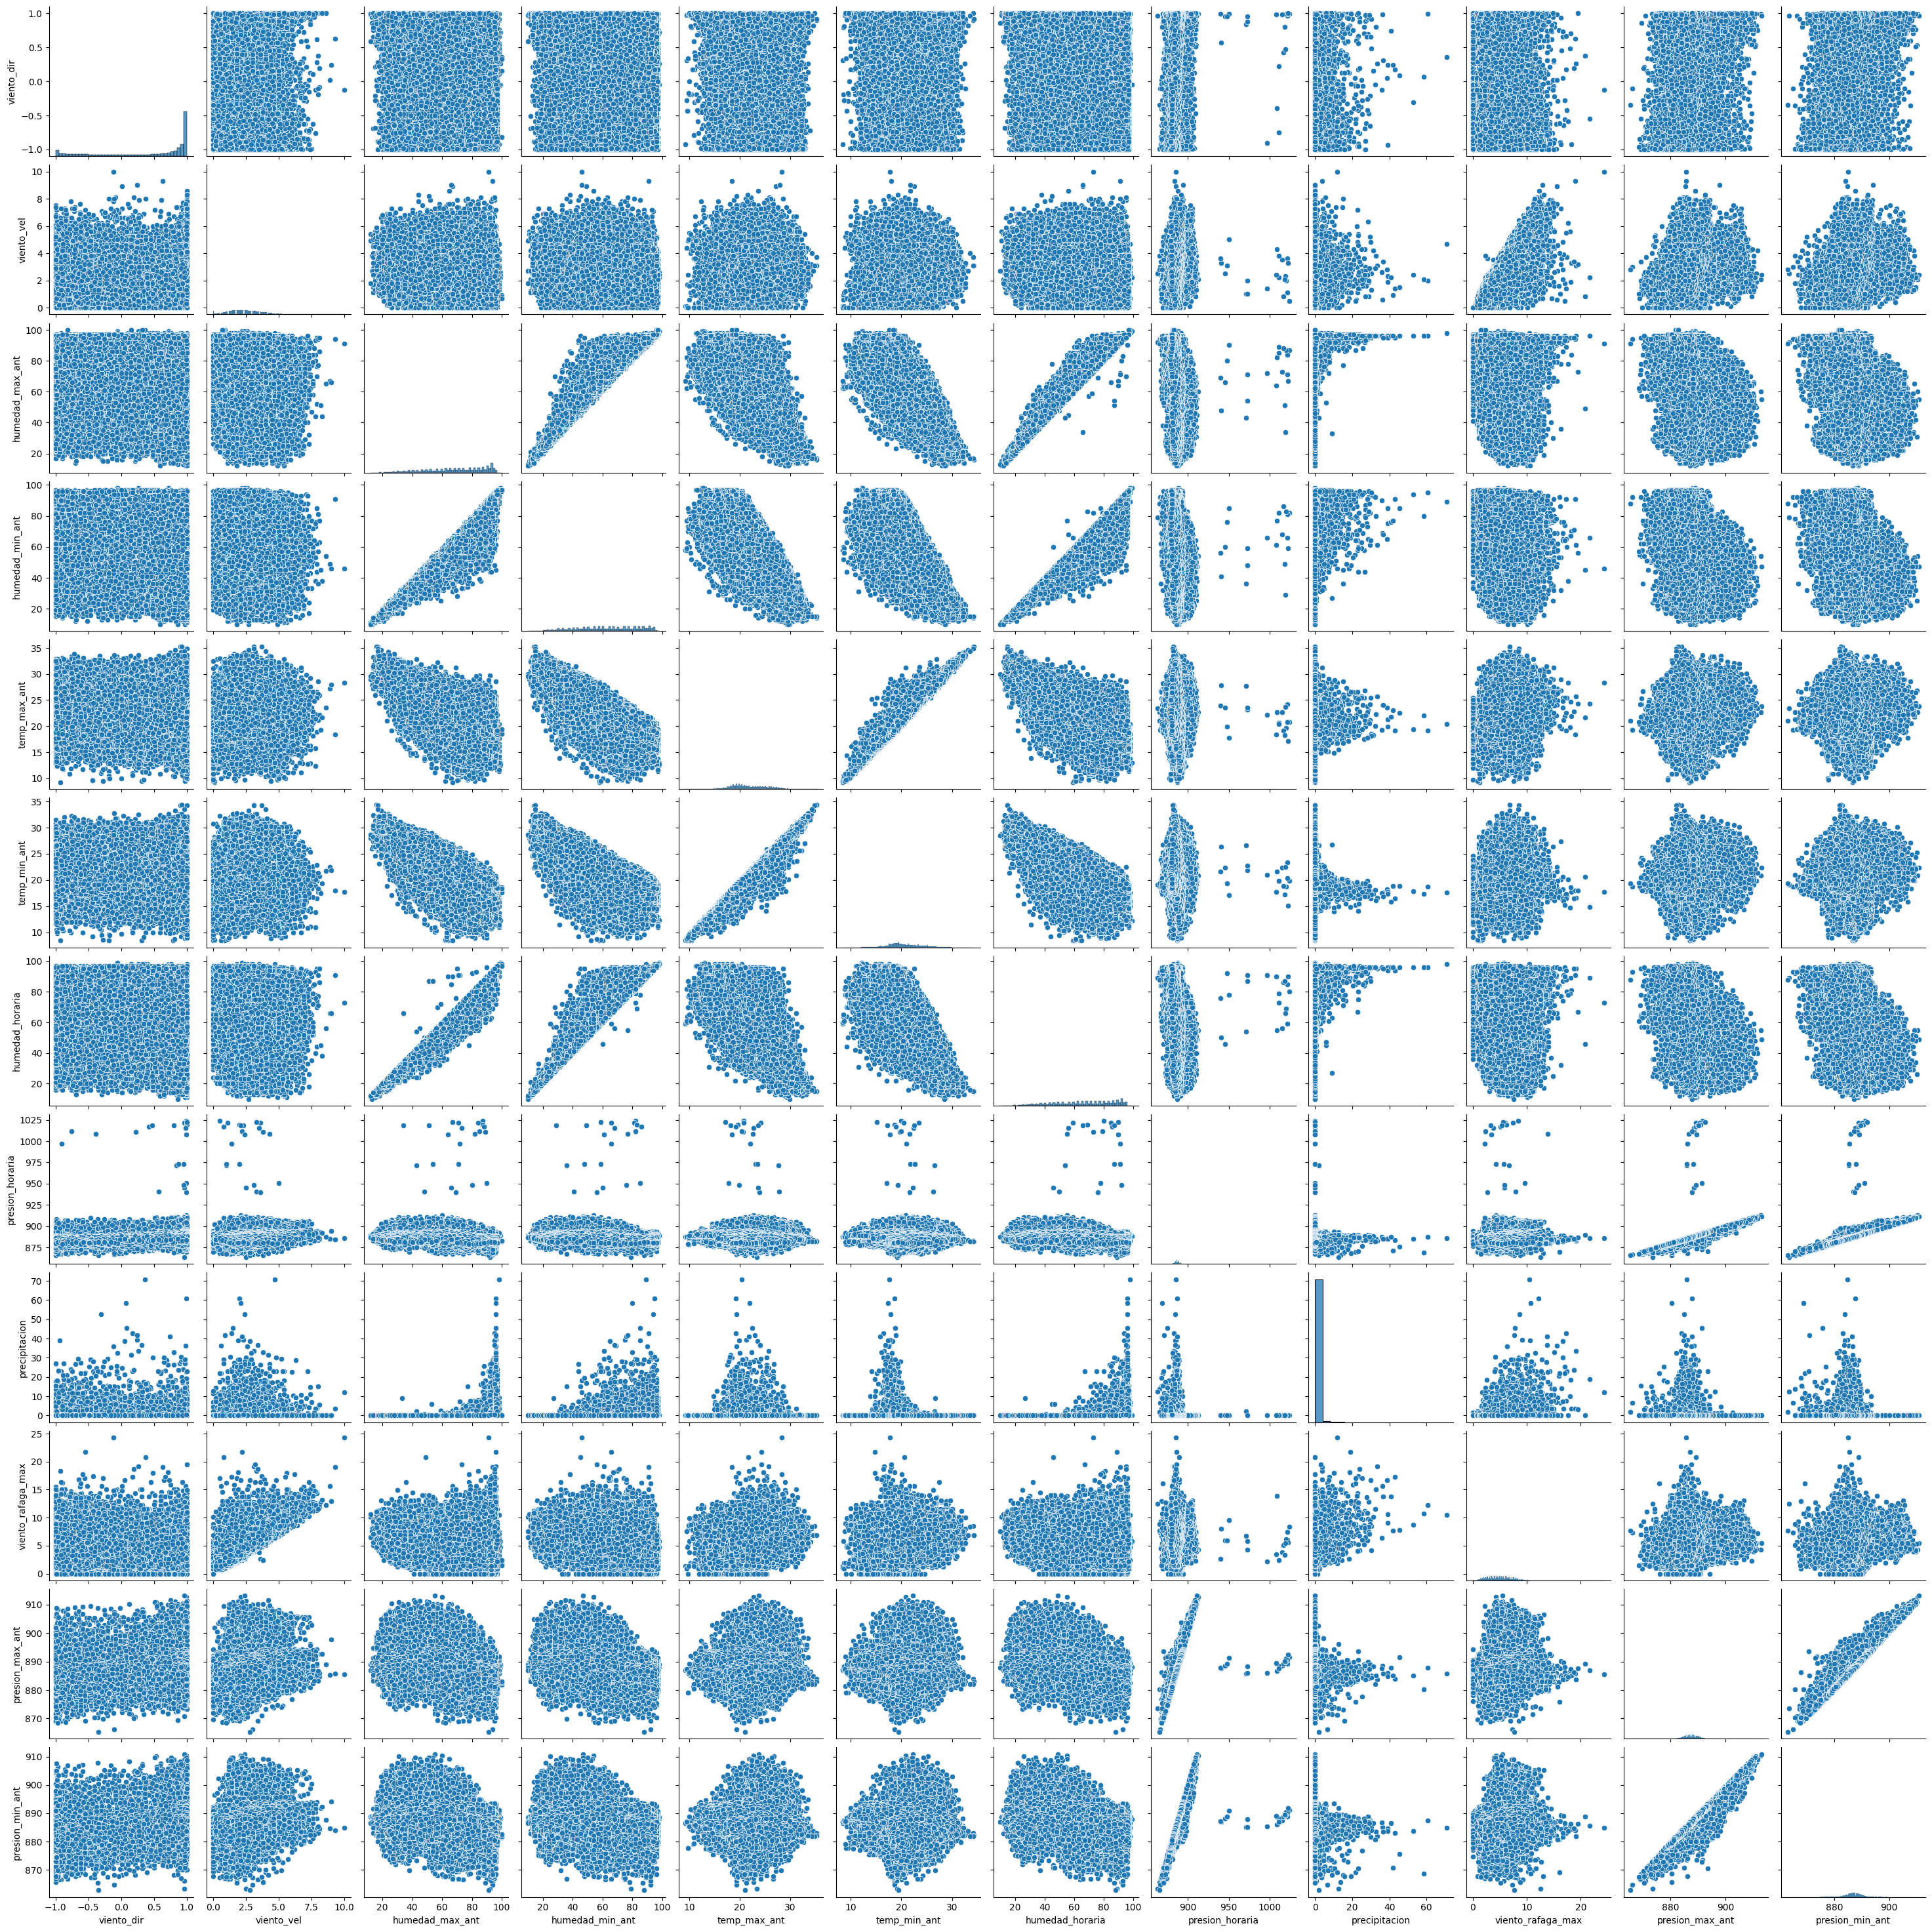

In [55]:
sns.pairplot(df)

En la figura anterior, se presenta un *pairplot* que muestra la relación entre cada par de variables analizadas. A partir de estos diagramas de dispersión, se identifican las siguientes relaciones que merecen un análisis más detallado:

-   `humedad_horaria` vs `temp_max_ant`
-   `humedad_horaria` vs `presion_max_ant`
-   `precipitacion` vs `temp_max_ant`
-   `precipitacion` vs `humedad_horaria`
-   `presion_max_ant` vs `temp_max_ant`
-   `viento_vel` vs `presion_max_ant`

A continuación, se procederá a examinar estas relaciones específicas con mayor profundidad.

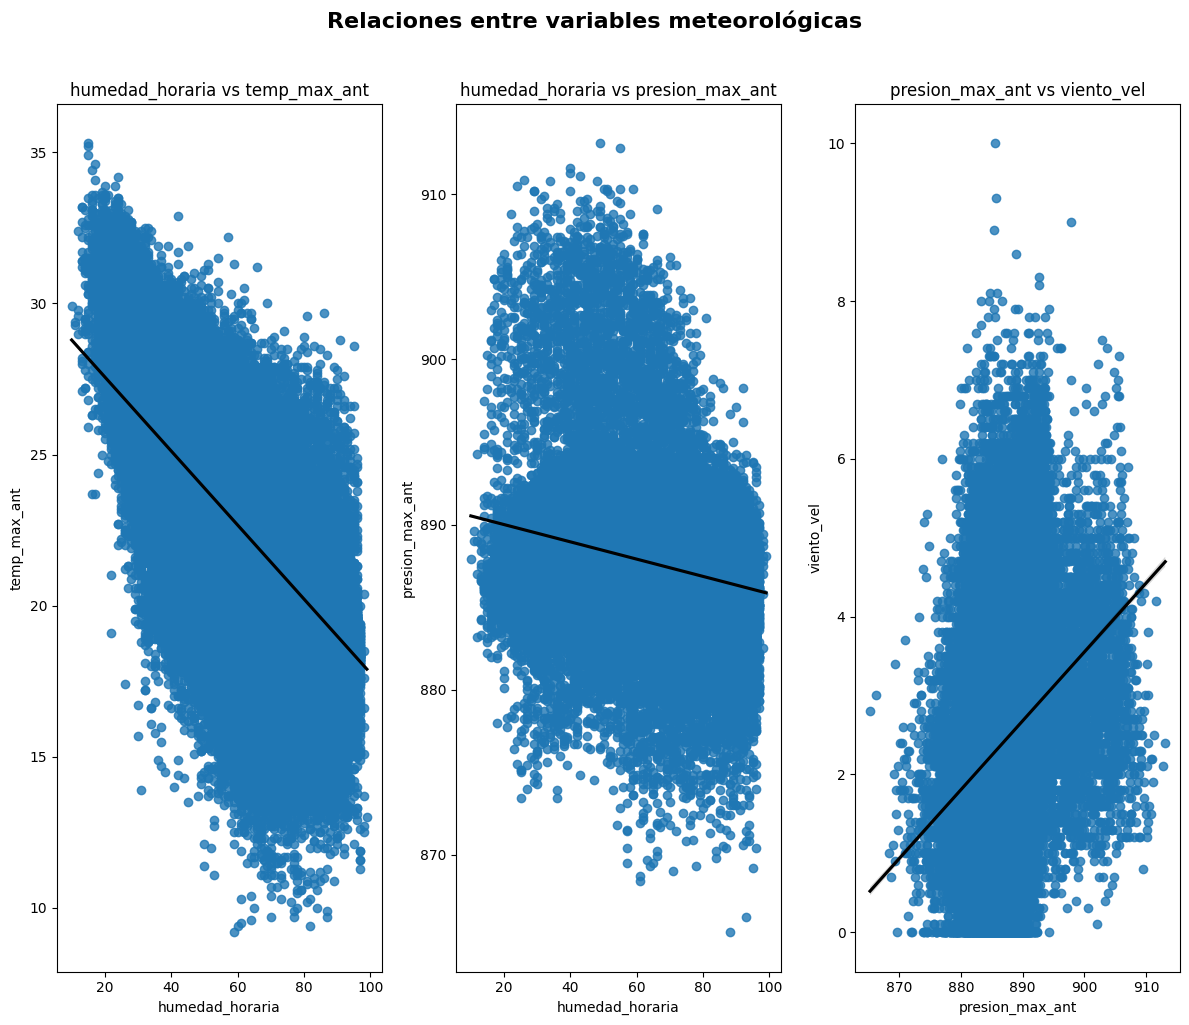

In [56]:
# Lista de pares (x, y) a graficar
# Pares originales (los vamos a invertir en el gráfico)
pares = [
    ('humedad_horaria','temp_max_ant'),
    ('humedad_horaria', 'presion_max_ant'),
    ('presion_max_ant', 'viento_vel')
]

# Crear figura con subplots: 1 fila, 2 columnas
fig, axes = plt.subplots(1, 3, figsize=(12, 10))
axes = axes.flatten()

# Graficar cada par con regplot
for i, (x, y) in enumerate(pares):
    sns.regplot(data=df, x=x, y=y, ax=axes[i],
                line_kws={'color': 'black'})
    axes[i].set_title(f'{x} vs {y}', fontsize=12)
    axes[i].set_xlabel(x)
    axes[i].set_ylabel(y)

# Título general
plt.suptitle('Relaciones entre variables meteorológicas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Relación entre humedad, temperatura y presión**

En el gráfico anterior se observa la relación entre la humedad horaria, la temperatura y la presión máxima. Mediante el regplot, se identifica una relación inversamente proporcional entre la humedad y estas dos variables: a medida que la humedad aumenta, tanto la temperatura como la presión tienden a disminuir. Este hallazgo resulta relevante, ya que podría influir en la predicción de la velocidad del viento.

Adicionalmente, se evidencia una relación directamente proporcional entre la presión y la velocidad del viento: cuando la presión aumenta, la velocidad del viento también lo hace. Estas correlaciones son determinantes para entender el comportamiento de la variable de respuesta y, por tanto, son clave para el desarrollo de la investigación.

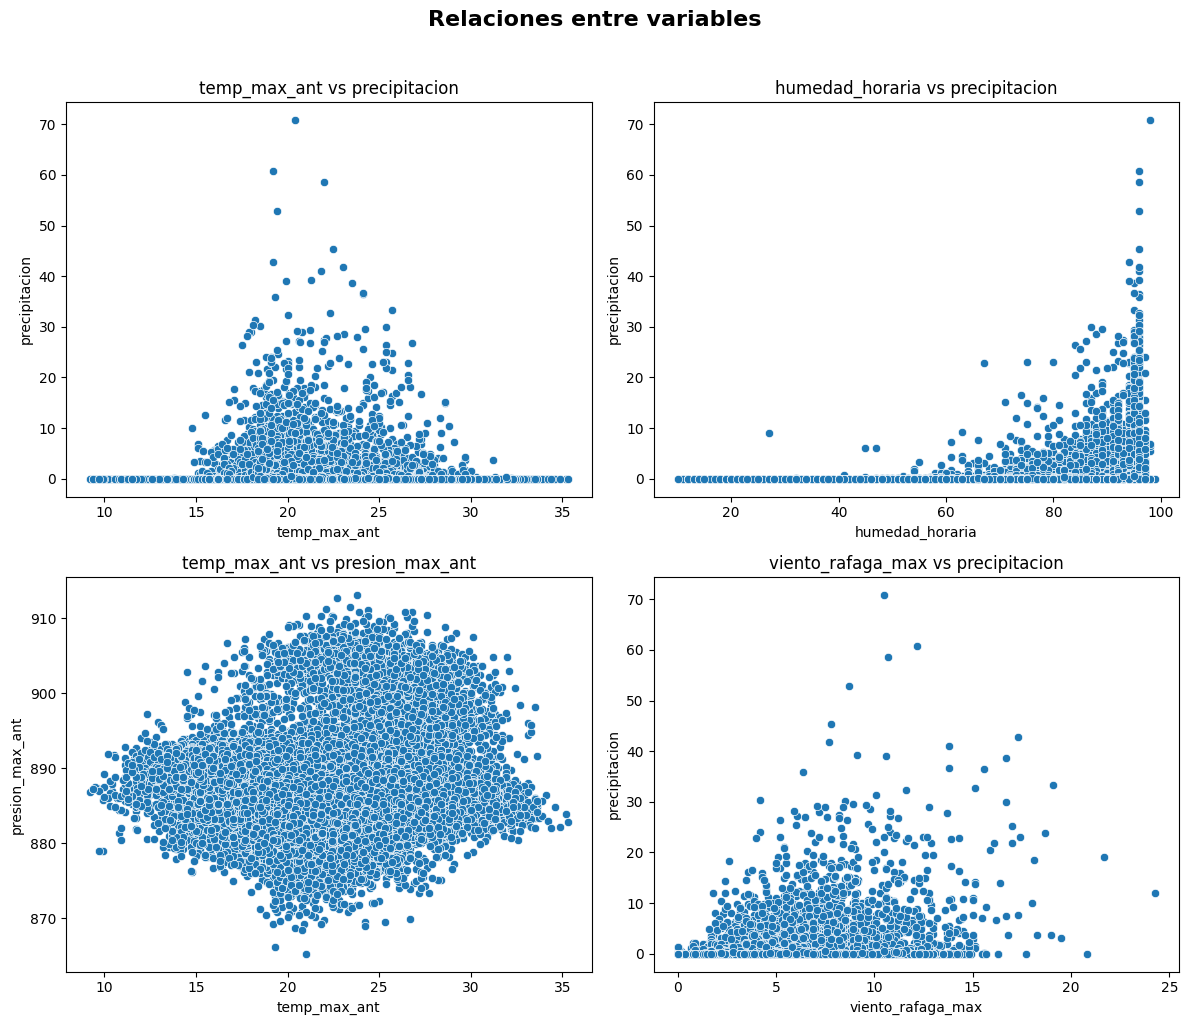

In [57]:
pares = [
    ('temp_max_ant', 'precipitacion'),
    ('humedad_horaria', 'precipitacion'),
    ('temp_max_ant', 'presion_max_ant'),
    ('viento_rafaga_max', 'precipitacion')
]

# Crear figura con subplots: 1 fila, 2 columnas
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Graficar cada par con regplot
for i, (x, y) in enumerate(pares):
    sns.scatterplot(data=df, x=x, y=y, ax=axes[i])
    axes[i].set_title(f'{x} vs {y}', fontsize=12)
    axes[i].set_xlabel(x)
    axes[i].set_ylabel(y)

# Título general
plt.suptitle('Relaciones entre variables', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

En la figura anterior, podemos observar relaciones y distribuciones entre las variables. La relación entre la temperatura máxima del día anterior y la precipitación no muestra un patrón claro, aunque la mayoría de los valores de precipitación se concentran cerca de cero, lo que sugiere una distribución sesgada hacia valores bajos. En el caso de la humedad horaria y la precipitación, sí se observa una relación positiva: a mayor humedad, tiende a haber más precipitación, aunque también con una alta concentración de ceros. La relación entre temperatura máxima anterior y presión máxima muestra una distribución en forma de nube densa sin una tendencia lineal clara, aunque se concentran en un rango específico de presión enytre 870 y 910. Por último, la relación entre ráfagas máximas de viento y precipitación también presenta una distribución con alta concentración en valores bajos de precipitación, pero se nota que los valores más altos de precipitación pueden asociarse con mayores ráfagas de viento.

Una vez realizado el analisis exploratorio, realizaremos el desarrollo de modelos de regresion para lograr predecir el valor de la velocidad del tiempo 

# Modelos de Regresión

Para los modelos de regresion, realizaremos una lista de modelos para poder tener un abanico de opciones que mejor logren entender el comportamiento de los datos. Estos modelos son los siguientes: 

| Modelo              |
|---------------------|
| K-NN                |
| Linear Regression   |
| Ridge               |
| Lasso               |
| Decision Tree       |
| Random Forest       |
| XGBoost             |
| SVM                 |
| MLP                 |
| RNN                 |
| LSTM                |

Para garantizar que los modelos desarrollados sean generalizables, se aplicará validación cruzada (cross-validation) mediante un enfoque de ventana deslizante (sliding window). Esta metodología se selecciona debido a que las particiones respetan la tendencia temporal de la velocidad del viento, evitando así problemas de fuga de datos (data leakage) y asegurando una evaluación realista.

En primer lugar, se instalarán y cargarán las librerías necesarias para el desarrollo de los modelos. El análisis comenzará con el modelo de regresión lineal (el más básico), seguido de técnicas más avanzadas en fases posteriores.

In [58]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from statsmodels.stats.diagnostic import acorr_ljungbox

#### Modelo de Regresión lineal

En el siguiente código se establece la configuración general para el desarrollo de los modelos, definiendo las variables independientes (predictoras) y la variable dependiente (objetivo).

Para este modelo en particular, se seleccionaron las variables analizadas durante el Análisis Exploratorio de Datos (EDA), basándose en los siguientes criterios:

Sensibilidad a multicolinealidad: El modelo requiere descartar variables altamente correlacionadas entre sí, ya que podrían explicar el mismo fenómeno (redundancia).
Relevancia estadística: Las variables elegidas demostraron patrones significativos durante el EDA.
Las variables finalmente incluidas son:

- `viento_rafaga_max`
- `humedad_horaria`
- `presion_max_ant`
- `temp_max_ant`


In [59]:
# CONFIGURACIÓN GENERAL 
features = [
        'temp_max_ant', 'humedad_horaria', 'viento_rafaga_max',
       'presion_max_ant']

target = 'viento_vel'

df = df.sort_values(by='hora').reset_index(drop=True)
train_size = int(len(df) * 0.8)
df_train = df.iloc[:train_size]
df_test = df.iloc[train_size:]

ventanas_dias = [7, 14, 21]
horas_por_dia = 24

# Crear lista vacía para guardar resultados
tabla_resultados_test = []


##### Entrenamiento del modelo

En la siguiente sección se presenta el código utilizado para el entrenamiento del modelo. El procedimiento seguido fue el siguiente:

Para respetar la naturaleza temporal de los datos y evitar fugas de información, se implementó una validación cruzada basada en series de tiempo. Se utilizó un esquema de ventana deslizante, donde el modelo se entrena con un número fijo de observaciones y luego se evalúa en un único día. Posteriormente, la ventana de entrenamiento avanza en el tiempo y el proceso se repite. Este método permite evaluar el desempeño del modelo de manera realista y consistente con su aplicación futura.

Inicialmente, los datos fueron divididos en conjuntos de entrenamiento y prueba. El conjunto de entrenamiento se empleó para entrenar los modelos, y dentro de este, se aplicó la validación cruzada mediante ventanas deslizantes, según el esquema previamente mencionado.

Para determinar el mejor desempeño, se seleccionó el modelo que obtuvo el menor valor de RMSE en la etapa de entrenamiento. Finalmente, se reentrenó el modelo seleccionado utilizando todo el conjunto de entrenamiento original y se evaluó su desempeño utilizando el conjunto de prueba que había sido separado al inicio.

Este mismo procedimiento será aplicado de manera consistente a todos los modelos de regresión desarrollados en el proyecto.

In [60]:
from sklearn.linear_model import LinearRegression

# RESULTADOS
resultados = []

for T_dias in ventanas_dias:
    T_horas = T_dias * horas_por_dia
    errores_val = []

    for i in range(0, len(df_train) - T_horas - horas_por_dia, horas_por_dia):
        train_data = df_train.iloc[i:i+T_horas]
        val_data = df_train.iloc[i+T_horas:i+T_horas+horas_por_dia]

        X_train = train_data[features]
        y_train = train_data[target]
        X_val = val_data[features]
        y_val = val_data[target]

        # Pipeline: escalado + modelo lineal
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('modelo', LinearRegression())
        ])

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_val)
        mse = mean_squared_error(y_val, y_pred)
        rmse = np.sqrt(mse)
        errores_val.append(rmse)

    promedio_rmse = np.mean(errores_val)
    resultados.append({
        'modelo': 'LinearRegression',
        'ventana_dias': T_dias,
        'rmse_validacion': promedio_rmse
    })
    
resultados_df = pd.DataFrame(resultados)
print(resultados_df)

             modelo  ventana_dias  rmse_validacion
0  LinearRegression             7         0.569932
1  LinearRegression            14         0.564264
2  LinearRegression            21         0.562489


El desempeño del modelo fue evaluado utilizando la métrica RMSE. Se observó que el modelo que obtuvo el menor valor de RMSE correspondió al entrenamiento realizado con una ventana deslizante de 21 días. Por lo tanto, se seleccionó este modelo para continuar con el proceso de evaluación y aplicación.

Para agilizar el proceso de desarrollo de modelos, se diseñó una función que calcula automáticamente las métricas de desempeño seleccionadas para cada modelo evaluado. Estas métricas se almacenan de manera sistemática en una tabla, permitiendo organizar y centralizar los resultados obtenidos. Al finalizar el análisis, esta tabla facilitará la comparación de los distintos modelos, proporcionando una base objetiva para concluir cuál presenta el mejor desempeño de acuerdo con los criterios establecidos.

In [61]:
def guardar_resultados_test(modelo_nombre, y_true, y_pred, param_str="-", ventana_dias=None):
    """Calcula métricas y guarda resultados en tabla_resultados_test"""

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))) * 100
    ljungbox = acorr_ljungbox(y_true - y_pred, lags=[10], return_df=True)['lb_pvalue'].iloc[0]

    tabla_resultados_test.append({
        'modelo': modelo_nombre,
        'ventana_dias': ventana_dias,
        'param': param_str,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'MAPE (%)': mape,
        'LjungBox p-value': ljungbox
    })

##### Resultados

In [62]:
# Selección de la mejor configuración
mejor_config = resultados_df.loc[resultados_df['rmse_validacion'].idxmin()]
T_final = int(mejor_config['ventana_dias'] * horas_por_dia)

# Preparación de datos
X_train_final = df_train[features].iloc[-T_final:]
y_train_final = df_train[target].iloc[-T_final:]
X_test = df_test[features]
y_test = df_test[target]

# Modelo final: LinearRegression
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LinearRegression())
])

# Entrenamiento y predicción
final_pipeline.fit(X_train_final, y_train_final)
y_test_pred = final_pipeline.predict(X_test)

# Guardar métricas con la función creada
guardar_resultados_test(
    modelo_nombre='LinearRegression',
    y_true=y_test,
    y_pred=y_test_pred,
    param_str='-',
    ventana_dias=int(mejor_config['ventana_dias'])
)

In [63]:
pd.DataFrame(tabla_resultados_test)

,modelo,ventana_dias,param,MAE,MSE,RMSE,R2,MAPE (%),LjungBox p-value
0,LinearRegression,21,-,0.530762,0.503996,0.709926,0.606147,32.247794,5.748761e-09


Los resultados presentados en la tabla corresponden a la evaluación del modelo Linear Regression sobre el conjunto de testing. El modelo, entrenado con una ventana deslizante de 21 días, obtuvo un RMSE de 0.709926, un MAE de 0.530762 y un R² de 0.606147, indicando un desempeño aceptable al explicar aproximadamente el 60% de la variabilidad de los datos de prueba. El MAPE fue de 32.25%, y el test de Ljung-Box mostró un valor de p muy bajo, sugiriendo la presencia de autocorrelación en los residuos.

#### Modelo Ridge y Lasso - Regresión

Para los siguientes modelos, dado que son de mayor complejidad y no presentan sensibilidad a la multicolinealidad, no será necesario realizar un análisis previo de este fenómeno sobre las variables. Por lo tanto, se trabajará directamente con todas las variables disponibles en la base de datos.


In [64]:
features = ['viento_dir','humedad_max_ant',
       'humedad_min_ant', 'temp_max_ant', 'temp_min_ant', 'humedad_horaria',
       'presion_horaria', 'precipitacion', 'viento_rafaga_max',
       'presion_max_ant', 'presion_min_ant']
target = 'viento_vel'

Teniendo en cuenta que todos los modelos serán entrenados bajo la misma metodología, se diseñó una función que automatiza el proceso de entrenamiento siguiendo los lineamientos planteados anteriormente. A continuación, se presenta la definición de dicha función en el código.

In [65]:
from sklearn.model_selection import ParameterGrid


def validacion_temporal_grid(
    df_train, features, target,
    modelo_cls, modelo_nombre,
    param_grid,
    ventanas_dias=[7, 14, 21],
    horas_por_dia=24
):
    resultados = []
    grid = list(ParameterGrid(param_grid))

    for params in grid:
        for T_dias in ventanas_dias:
            T_horas = T_dias * horas_por_dia
            errores_val = []

            for i in range(0, len(df_train) - T_horas - horas_por_dia, horas_por_dia):
                train_data = df_train.iloc[i:i+T_horas]
                val_data = df_train.iloc[i+T_horas:i+T_horas+horas_por_dia]

                X_train = train_data[features]
                y_train = train_data[target]
                X_val = val_data[features]
                y_val = val_data[target]

                pipeline = Pipeline([
                    ('scaler', StandardScaler()),
                    ('modelo', modelo_cls(**params))
                ])

                pipeline.fit(X_train, y_train)
                y_pred = pipeline.predict(X_val)
                mse = mean_squared_error(y_val, y_pred)
                rmse = np.sqrt(mse)
                errores_val.append(rmse)

            promedio_rmse = np.mean(errores_val)
            resultados.append({
                'modelo': modelo_nombre,
                'params': params,
                'ventana_dias': T_dias,
                'rmse_validacion': promedio_rmse
            })

    return pd.DataFrame(resultados)


En esta sección se lleva a cabo el entrenamiento y validación de los modelos Ridge y Lasso, identificando los mejores hiperparámetros para cada uno de ellos.

```python
from sklearn.linear_model import Ridge, Lasso

# Grid para Ridge
param_grid_ridge = {
    'alpha': [0.01, 0.1,0.0001, 1.0],
}

resultados_ridge = validacion_temporal_grid(
    df_train=df_train,
    features=features,
    target=target,
    modelo_cls=Ridge,
    modelo_nombre='Ridge',
    param_grid=param_grid_ridge,
    ventanas_dias=[7, 14, 21]
)

# Mostrar los mejores resultados
print(resultados_ridge.sort_values('rmse_validacion'))



In [66]:
resultados_ridge = pd.DataFrame([
    {
        'modelo': 'Ridge',
        'params': {
            'alpha': 1.0
        },
        'ventana_dias': 21,
        'rmse_validacion': 0.544432
    }
])

resultados_ridge

,modelo,params,ventana_dias,rmse_validacion
0,Ridge,{'alpha': 1.0},21,0.544432


```python
from sklearn.linear_model import Ridge, Lasso

# Grid para Lasso
param_grid_lasso = {
    'alpha': [0.01, 0.1,0.0001, 1.0],
}

resultados_lasso = validacion_temporal_grid(
    df_train=df_train,
    features=features,
    target=target,
    modelo_cls=Lasso,
    modelo_nombre='Lasso',
    param_grid=param_grid_lasso,
    ventanas_dias=[7, 14, 21]
)

# Mostrar los mejores resultados
print(resultados_lasso.sort_values('rmse_validacion'))


In [ ]:

resultados_lasso = pd.DataFrame([
    {
        'modelo': 'Lasso',
        'params': {
            'alpha': 0.0001
        },
        'ventana_dias': 21,
        'rmse_validacion': 0.547084
    }
])

resultados_lasso

Se presentan los resultados de los modelos Ridge y Lasso. Ambos modelos muestran desempeños muy similares; sin embargo, el modelo Ridge obtuvo un menor valor de RMSE durante la fase de validación, por lo que se considera como el de mejor rendimiento. Aunque ambos modelos comparten un mismo origen en cuanto a su propósito de regularización, difieren en su enfoque: Ridge aplica una penalización basada en la norma L2, que tiende a reducir los coeficientes pero sin llevarlos exactamente a cero, mientras que Lasso utiliza una penalización basada en la norma L1, promoviendo la selección de variables al forzar algunos coeficientes a ser exactamente cero. Esta diferencia en la forma de regularizar puede influir en el comportamiento final del modelo, especialmente en conjuntos de datos con alta multicolinealidad o gran cantidad de variables.

Para evaluar el modelo de manera más eficiente, se diseñó una función que generaliza el proceso de selección de los mejores hiperparámetros, el entrenamiento final y la prueba del modelo. Además, se integró en esta función el cálculo de métricas presentado anteriormente, lo que permite agilizar considerablemente el desarrollo y la evaluación de los modelos posteriores.

In [68]:
def evaluar_mejores_modelos_en_test(
    resultados_validacion,
    df_train, df_test,
    features, target,
    modelos_dict,
    horas_por_dia=24
):
    mejores_configs = resultados_validacion.loc[
        resultados_validacion.groupby('modelo')['rmse_validacion'].idxmin()
    ]

    for _, fila in mejores_configs.iterrows():
        modelo_nombre = fila['modelo']
        modelo_cls = modelos_dict[modelo_nombre]
        params = fila['params']
        ventana_dias = fila['ventana_dias']
        T_final = int(ventana_dias * horas_por_dia)

        # Preparar datos
        X_train_final = df_train[features].iloc[-T_final:]
        y_train_final = df_train[target].iloc[-T_final:]
        X_test = df_test[features]
        y_test = df_test[target]

        # Modelo con parámetros óptimos
        modelo_final = modelo_cls(**params)
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('modelo', modelo_final)
        ])
        pipeline.fit(X_train_final, y_train_final)
        y_pred = pipeline.predict(X_test)

        # Guardar resultados
        guardar_resultados_test(
            modelo_nombre=modelo_nombre,
            y_true=y_test,
            y_pred=y_pred,
            param_str=str(params),
            ventana_dias=ventana_dias
        )

En la siguiente línea de código se muestra la aplicación de la función previamente diseñada para entrenar y evaluar los modelos Ridge y Lasso.

##### Resultados

In [ ]:
from sklearn.linear_model import Ridge, Lasso

modelos_dict = {
    'Ridge': Ridge,
}

resultados_ridge = pd.DataFrame([
    {
        'modelo': 'Ridge',
        'params': {
            'alpha': 1.0
        },
        'ventana_dias': 21,
        'rmse_validacion': 0.544432
    }
])

evaluar_mejores_modelos_en_test(
    resultados_validacion=resultados_ridge,
    df_train=df_train,
    df_test=df_test,
    features=features,
    target=target,
    modelos_dict=modelos_dict,
    horas_por_dia=24
)

modelos_dict2 = {
    'Lasso': Lasso,
}

evaluar_mejores_modelos_en_test(
    resultados_validacion=resultados_lasso,
    df_train=df_train,
    df_test=df_test,
    features=features,
    target=target,
    modelos_dict=modelos_dict2,
    horas_por_dia=24
)

pd.DataFrame(tabla_resultados_test)

,modelo,ventana_dias,param,MAE,MSE,RMSE,R2,MAPE (%),LjungBox p-value
0,LinearRegression,21,-,0.530762,0.503996,0.709926,0.606147,32.247794,5.748761e-09
1,Ridge,21,{'alpha': 1.0},0.531421,0.491149,0.700820,0.616186,32.383334,7.534636e-13
2,Lasso,21,{'alpha': 0.0001},0.533032,0.493721,0.702653,0.614176,32.424104,9.837321e-13


Al finalizar el desarrollo de todos los modelos, se realizará una comparación de sus resultados con el objetivo de seleccionar el modelo que presente el mejor desempeño.

#### Modelo KNN - Regresión

Cargamos la librerias y procedemos con el desarrollo del modelo KNN.

In [70]:
from sklearn.neighbors import KNeighborsRegressor

# Param grid
param_grid_knn = {
    'n_neighbors': [3, 4,5,7,9],
}

resultados_knn = validacion_temporal_grid(
    df_train=df_train,
    features=features,
    target=target,
    modelo_cls=KNeighborsRegressor,
    modelo_nombre='knn',
    param_grid=param_grid_knn,
    ventanas_dias=[7, 14, 21]
)

# Mostrar los mejores resultados
print(resultados_knn.sort_values('rmse_validacion'))

   modelo              params  ventana_dias  rmse_validacion
11    knn  {'n_neighbors': 7}            21         0.668529
14    knn  {'n_neighbors': 9}            21         0.669758
8     knn  {'n_neighbors': 5}            21         0.673582
5     knn  {'n_neighbors': 4}            21         0.680004
10    knn  {'n_neighbors': 7}            14         0.692158
7     knn  {'n_neighbors': 5}            14         0.694291
2     knn  {'n_neighbors': 3}            21         0.695332
13    knn  {'n_neighbors': 9}            14         0.695367
4     knn  {'n_neighbors': 4}            14         0.699936
1     knn  {'n_neighbors': 3}            14         0.713654
6     knn  {'n_neighbors': 5}             7         0.741118
9     knn  {'n_neighbors': 7}             7         0.744042
3     knn  {'n_neighbors': 4}             7         0.745248
12    knn  {'n_neighbors': 9}             7         0.751849
0     knn  {'n_neighbors': 3}             7         0.755824


Se presentan los resultados del modelo K-Nearest Neighbors (KNN) evaluado bajo distintas combinaciones de hiperparámetro n_neighbors y tamaños de ventana de entrenamiento (ventana_días). El desempeño de cada configuración se midió mediante el RMSE de validación.

Se observa que los mejores resultados, es decir, los menores valores de RMSE, se obtuvieron utilizando una ventana de 21 días. En particular, las configuraciones con n_neighbors = 7 (RMSE = 0.668529) y n_neighbors = 9 (RMSE = 0.669758) presentaron los mejores desempeños, con diferencias mínimas entre ellas. A medida que se reduce el tamaño de la ventana de entrenamiento a 14 o 7 días, el RMSE tiende a aumentar, indicando que una mayor cantidad de datos históricos para el entrenamiento mejora el rendimiento del modelo.

Por ende, el mejor modelo corresponde a KNN con 7 vecinos y ventana de 21 días, basado en el menor valor de RMSE de validación obtenido.

##### Resultados

In [71]:
modelos_dict3 = {
    'knn': KNeighborsRegressor,
}

evaluar_mejores_modelos_en_test(
    resultados_validacion=resultados_knn,
    df_train=df_train,
    df_test=df_test,
    features=features,
    target=target,
    modelos_dict=modelos_dict3,
    horas_por_dia=24
)

pd.DataFrame(tabla_resultados_test)

,modelo,ventana_dias,param,MAE,MSE,RMSE,R2,MAPE (%),LjungBox p-value
0,LinearRegression,21,-,0.530762,0.503996,0.709926,0.606147,32.247794,5.748761e-09
1,Ridge,21,{'alpha': 1.0},0.531421,0.491149,0.700820,0.616186,32.383334,7.534636e-13
2,Lasso,21,{'alpha': 0.0001},0.533032,0.493721,0.702653,0.614176,32.424104,9.837321e-13
3,knn,21,{'n_neighbors': 7},0.604018,0.609743,0.780861,0.523509,42.895575,3.703323e-44


En el código anterior se observan las diferencias en el desempeño entre el modelo KNN y los demás modelos evaluados. Si bien en algunas métricas se evidencian mejoras, se mantiene una tendencia clara: en todos los modelos probados hasta el momento, el uso de una ventana deslizante de 21 días ha producido los mejores resultados.

#### Modelo: Árboles de Decisión - Regresión

A continuación, se continuará con el desarrollo del modelo de árbol de decisión para la tarea de regresión. Debido a las limitaciones de tiempo de procesamiento en este Jupyter Book, a partir de este modelo se presentarán directamente los códigos y, en función de los resultados obtenidos, se definirán los mejores hiperparámetros con los cuales se realizará el entrenamiento final de cada modelo.

```python

from sklearn.tree import DecisionTreeRegressor

# Param grid
param_grid_dt = {
    'max_depth': [3, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

resultados_dt = validacion_temporal_grid(
    df_train=df_train,
    features=features,
    target=target,
    modelo_cls=DecisionTreeRegressor,
    modelo_nombre='DecisionTree',
    param_grid=param_grid_dt,
    ventanas_dias=[7, 14, 21]
)

# Mostrar los mejores resultados
print(resultados_dt.sort_values('rmse_validacion').head(5))

##### Resultados

In [72]:
from sklearn.tree import DecisionTreeRegressor

resultados_dt = pd.DataFrame([
    {
        'modelo': 'DecisionTree',
        'params': {'max_depth': 3, 'min_samples_split': 2},
        'ventana_dias': 21,
        'rmse_validacion': 0.614974
    }])


modelos_dict4 = {
    'DecisionTree': DecisionTreeRegressor,
}

evaluar_mejores_modelos_en_test(
    resultados_validacion=resultados_dt,
    df_train=df_train,
    df_test=df_test,
    features=features,
    target=target,
    modelos_dict=modelos_dict4,
    horas_por_dia=24
)

pd.DataFrame(tabla_resultados_test)

,modelo,ventana_dias,param,MAE,MSE,RMSE,R2,MAPE (%),LjungBox p-value
0,LinearRegression,21,-,0.530762,0.503996,0.709926,0.606147,32.247794,5.748761e-09
1,Ridge,21,{'alpha': 1.0},0.531421,0.491149,0.700820,0.616186,32.383334,7.534636e-13
2,Lasso,21,{'alpha': 0.0001},0.533032,0.493721,0.702653,0.614176,32.424104,9.837321e-13
3,knn,21,{'n_neighbors': 7},0.604018,0.609743,0.780861,0.523509,42.895575,3.703323e-44
4,DecisionTree,21,"{'max_depth': 3, 'min_samples_split': 2}",0.567094,0.542789,0.736742,0.575832,33.822034,7.783506e-08


El modelo Decision Tree presentó un desempeño aceptable, con un RMSE de 0.736742 y un R² de 0.575832. Aunque sus resultados son competitivos, fueron superados por modelos más simples como Ridge y Lasso en términos de menor error de predicción y mayor capacidad explicativa.

#### Modelo Random Forest - Regresión

El modelo con el que continuaremos es de mayor complejidad, lo que implica tiempos de procesamiento más largos. No obstante, su alta capacidad para aprender patrones complejos lo convierte en una opción robusta y prometedora para la tarea planteada.

```python
from sklearn.ensemble import RandomForestRegressor

# 1. Definir el grid de hiperparámetros
param_grid_rf = {
    'n_estimators': [50],
    'max_depth': [10],
}

# 2. Ejecutar la validación temporal
resultados_rf = validacion_temporal_grid(
    df_train=df_train,
    features=features,
    target=target,
    modelo_cls=RandomForestRegressor,
    modelo_nombre='RandomForest',
    param_grid=param_grid_rf,
    ventanas_dias=[7, 14, 21]
)

# 3. Ver los mejores resultados
print(resultados_rf.sort_values('rmse_validacion').head(5))

##### Resultados

In [73]:
from sklearn.ensemble import RandomForestRegressor

resultados_rf = pd.DataFrame([
    {
        'modelo': 'RandomForest',
        'params': {'max_depth': 10, 'n_estimators': 50},
        'ventana_dias': 21,
        'rmse_validacion': 0.567283
    }])

modelos_dict5 = {
    'RandomForest': RandomForestRegressor
}

evaluar_mejores_modelos_en_test(
    resultados_validacion=resultados_rf,
    df_train=df_train,
    df_test=df_test,
    features=features,
    target=target,
    modelos_dict=modelos_dict5,
    horas_por_dia=24
)

pd.DataFrame(tabla_resultados_test)

,modelo,ventana_dias,param,MAE,MSE,RMSE,R2,MAPE (%),LjungBox p-value
0,LinearRegression,21,-,0.530762,0.503996,0.709926,0.606147,32.247794,5.748761e-09
1,Ridge,21,{'alpha': 1.0},0.531421,0.491149,0.700820,0.616186,32.383334,7.534636e-13
2,Lasso,21,{'alpha': 0.0001},0.533032,0.493721,0.702653,0.614176,32.424104,9.837321e-13
3,knn,21,{'n_neighbors': 7},0.604018,0.609743,0.780861,0.523509,42.895575,3.703323e-44
4,DecisionTree,21,"{'max_depth': 3, 'min_samples_split': 2}",0.567094,0.542789,0.736742,0.575832,33.822034,7.783506e-08
5,RandomForest,21,"{'max_depth': 10, 'n_estimators': 50}",0.537819,0.496161,0.704387,0.612269,33.419436,4.544621e-08


El modelo Random Forest mostró un buen desempeño, alcanzando un RMSE de 0.704387 y un R² de 0.612269, superando a modelos como KNN y Decision Tree. Su capacidad para reducir el error y explicar mejor la variabilidad lo posiciona como uno de los modelos más sólidos hasta este punto.

#### Modelo XGBoost - Regresión

Desarrollaremos el modelo XGBoost, una versión optimizada y potenciada de los algoritmos de árboles de decisión tradicionales, caracterizada por su alta eficiencia, capacidad de generalización y excelente desempeño en tareas de regresión y clasificación.

```python

from xgboost import XGBRegressor

# 1. Definir el grid de hiperparámetros para XGBoost
param_grid_xgb = {
    'n_estimators': [50],
    'max_depth': [5],
    'learning_rate': [0.01]
}

# 2. Ejecutar la validación temporal con XGBRegressor
resultados_xgb = validacion_temporal_grid(
    df_train=df_train,
    features=features,
    target=target,
    modelo_cls=XGBRegressor,
    modelo_nombre='XGBoost',
    param_grid=param_grid_xgb,
    ventanas_dias=[7, 14, 21]
)

# 3. Ver los mejores resultados
print(resultados_xgb.sort_values('rmse_validacion').head(5))

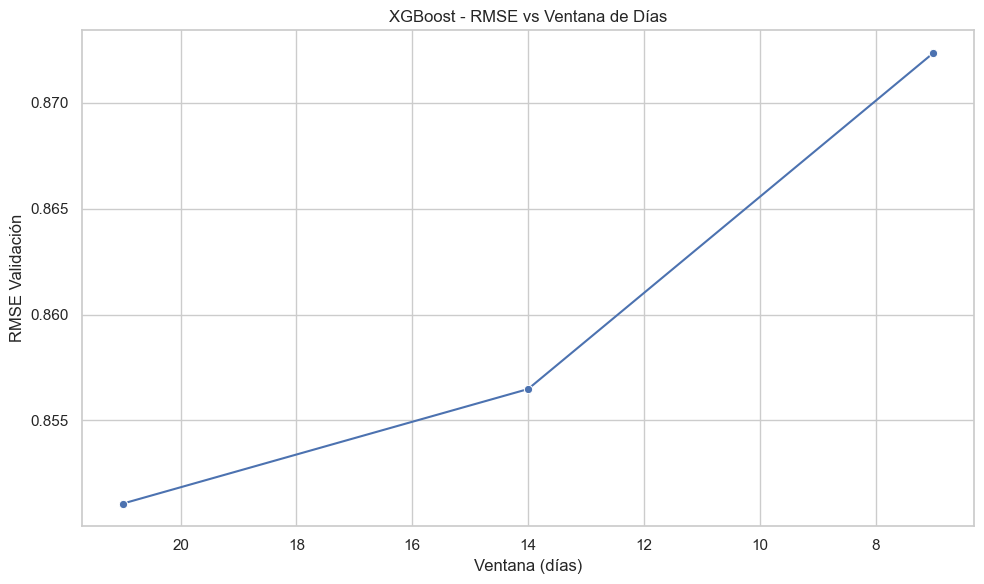

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Reconstruir el DataFrame basado en los datos que pasaste
resultados_xgb = pd.DataFrame([
    {
        'modelo': 'XGBoost',
        'params': {
            'learning_rate': 0.01,
            'max_depth': 5,
            'n_estimators': 100
        },
        'ventana_dias': 21,
        'rmse_validacion': 0.851075
    },
    {
        'modelo': 'XGBoost',
        'params': {
            'learning_rate': 0.01,
            'max_depth': 5,
            'n_estimators': 100
        },
        'ventana_dias': 14,
        'rmse_validacion': 0.856483
    },
    {
        'modelo': 'XGBoost',
        'params': {
            'learning_rate': 0.01,
            'max_depth': 5,
            'n_estimators': 100
        },
        'ventana_dias': 7,
        'rmse_validacion': 0.872350
    }
])

# 2. Crear layout para graficar
fig, axes = plt.subplots(1, 1, figsize=(10, 6))  # Solo un gráfico en este caso

# 3. Gráfico de líneas (eje x = ventana_dias, eje y = rmse_validacion)
sns.set(style="whitegrid")
sns.lineplot(
    x='ventana_dias',
    y='rmse_validacion',
    data=resultados_xgb,
    marker='o',
    ax=axes
)

axes.set_title('XGBoost - RMSE vs Ventana de Días')
axes.set_xlabel('Ventana (días)')
axes.set_ylabel('RMSE Validación')
axes.invert_xaxis()  # Opcional: para que 21,14,7 quede de izquierda a derecha
plt.tight_layout()
plt.show()

La gráfica muestra que a medida que disminuye el tamaño de la ventana de días, el RMSE de validación del modelo XGBoost tiende a aumentar. Esto indica que usar una mayor cantidad de días en la ventana de entrenamiento (especialmente 21 días) permite al modelo lograr un mejor desempeño predictivo, reduciendo el error.

##### Resultados

In [74]:
from xgboost import XGBRegressor

resultados_xgb = pd.DataFrame([
    {
        'modelo': 'XGBoost',
        'params': {
            'learning_rate': 0.01,
            'max_depth': 5,
            'n_estimators': 100
        },
        'ventana_dias': 21,
        'rmse_validacion': 0.851075
    }])

modelos_dict6 = {
    'XGBoost': XGBRegressor
}

evaluar_mejores_modelos_en_test(
    resultados_validacion=resultados_xgb,
    df_train=df_train,
    df_test=df_test,
    features=features,
    target=target,
    modelos_dict=modelos_dict6,
    horas_por_dia=24
)

pd.DataFrame(tabla_resultados_test)

,modelo,ventana_dias,param,MAE,MSE,RMSE,R2,MAPE (%),LjungBox p-value
0,LinearRegression,21,-,0.530762,0.503996,0.709926,0.606147,32.247794,5.748761e-09
1,Ridge,21,{'alpha': 1.0},0.531421,0.491149,0.700820,0.616186,32.383334,7.534636e-13
2,Lasso,21,{'alpha': 0.0001},0.533032,0.493721,0.702653,0.614176,32.424104,9.837321e-13
3,knn,21,{'n_neighbors': 7},0.604018,0.609743,0.780861,0.523509,42.895575,3.703323e-44
4,DecisionTree,21,"{'max_depth': 3, 'min_samples_split': 2}",0.567094,0.542789,0.736742,0.575832,33.822034,7.783506e-08
5,RandomForest,21,"{'max_depth': 10, 'n_estimators': 50}",0.537819,0.496161,0.704387,0.612269,33.419436,4.544621e-08
6,XGBoost,21,"{'learning_rate': 0.01, 'max_depth': 5, 'n_est...",0.602743,0.611995,0.782301,0.521749,44.717257,2.262960e-102


El modelo XGBoost presentó un desempeño inferior en comparación con otros modelos, con un RMSE de 0.782301 y un R² de 0.521749, además de un MAPE más elevado. Aunque es un modelo potente, en este caso no logró superar a modelos más simples como Ridge o Linear Regression.

### Modelo Support Vector Machine (SVM) - Regresión

e probará el modelo SVM ajustando sus diferentes hiperparámetros, incluyendo el tipo de kernel, que definirá la metodología de clasificación utilizada por el modelo.

```python
from sklearn.svm import SVR

# 1. Definir el grid de hiperparámetros para SVM
param_grid_svm = {
    'kernel': ['linear', 'rbf'],  # Tipo de kernel
    'C': [0.1,1],                  # Parámetro de regularización
    'gamma': [0.01,1], # Coeficiente para kernel 'rbf'/'poly'
    'epsilon': [0.01,0.1]         # Margen de error en SVR
}

# 3. Ejecutar la validación temporal con SVR
resultados_svm = validacion_temporal_grid(
    df_train=df_train,
    features=features,
    target=target,
    modelo_cls=SVR,  # Usamos el pipeline
    modelo_nombre='SVM',
    param_grid=param_grid_svm,
    ventanas_dias=[7, 14, 21]
)

# 4. Ver los mejores resultados
print(resultados_svm.sort_values('rmse_validacion').head(5))

##### Resultados

In [75]:
from sklearn.svm import SVR

resultados_svm = pd.DataFrame([
    {
        'modelo': 'SVM',
        'params': {
            'C': 0.1,
            'epsilon': 0.1,
            'gamma': 1,
            'kernel': 'rbf'
        },
        'ventana_dias': 21,
        'rmse_validacion': 0.547050
    }])

modelos_dict7 = {
    'SVM': SVR
}

evaluar_mejores_modelos_en_test(
    resultados_validacion=resultados_svm,
    df_train=df_train,
    df_test=df_test,
    features=features,
    target=target,
    modelos_dict=modelos_dict7,
    horas_por_dia=24
)

pd.DataFrame(tabla_resultados_test)

,modelo,ventana_dias,param,MAE,MSE,RMSE,R2,MAPE (%),LjungBox p-value
0,LinearRegression,21,-,0.530762,0.503996,0.709926,0.606147,32.247794,5.748761e-09
1,Ridge,21,{'alpha': 1.0},0.531421,0.491149,0.700820,0.616186,32.383334,7.534636e-13
2,Lasso,21,{'alpha': 0.0001},0.533032,0.493721,0.702653,0.614176,32.424104,9.837321e-13
3,knn,21,{'n_neighbors': 7},0.604018,0.609743,0.780861,0.523509,42.895575,3.703323e-44
4,DecisionTree,21,"{'max_depth': 3, 'min_samples_split': 2}",0.567094,0.542789,0.736742,0.575832,33.822034,7.783506e-08
5,RandomForest,21,"{'max_depth': 10, 'n_estimators': 50}",0.537819,0.496161,0.704387,0.612269,33.419436,4.544621e-08
6,XGBoost,21,"{'learning_rate': 0.01, 'max_depth': 5, 'n_est...",0.602743,0.611995,0.782301,0.521749,44.717257,2.262960e-102
7,SVM,21,"{'C': 0.1, 'epsilon': 0.1, 'gamma': 1, 'kernel...",0.858822,1.174568,1.083775,0.082121,67.470127,0.000000e+00


Se observa que el modelo SVM obtuvo el peor desempeño entre todos los modelos evaluados, presentando un RMSE superior a 1. Esto demuestra que, aunque se trate de un modelo más complejo, su complejidad no garantiza un mejor ajuste ni lo convierte necesariamente en la opción más adecuada para este problema.


#### Modelo ANN Multi Layer Perceptron (MLP) - Regresión

A continuación, se desarrollará un modelo de redes neuronales MLP con el objetivo de definir el mejor modelo de regresión.

```python

from sklearn.neural_network import MLPRegressor

param_grid_MLP = {
    'hidden_layer_sizes': [(5,), (10,)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.01],
    'learning_rate_init': [0.01],
    'max_iter': [200]
}

# 3. Ejecutar la validación temporal con SVR
resultados_mlp = validacion_temporal_grid(
    df_train=df_train,
    features=features,
    target=target,
    modelo_cls=MLPRegressor,  # Usamos el pipeline
    modelo_nombre='MLP',
    param_grid=param_grid_MLP,
    ventanas_dias=[7, 14, 21]
)

# 4. Ver los mejores resultados
print(resultados_mlp.sort_values('rmse_validacion').head(5))

In [37]:
from sklearn.neural_network import MLPRegressor
resultados_mlp = pd.DataFrame([
    {
        'modelo': 'MLP',
        'params': {
            'activation': 'tanh',
            'alpha': 0.01,
            'hidden_layer_sizes': (50,)
        },
        'ventana_dias': 21,
        'rmse_validacion': 0.558041
    }])

modelos_dict8 = {
    'MLP': MLPRegressor
}

evaluar_mejores_modelos_en_test(
    resultados_validacion=resultados_mlp,
    df_train=df_train,
    df_test=df_test,
    features=features,
    target=target,
    modelos_dict=modelos_dict8,
    horas_por_dia=24
)

pd.DataFrame(tabla_resultados_test)

,modelo,ventana_dias,param,MAE,MSE,RMSE,R2,MAPE (%),LjungBox p-value
0,LinearRegression,21,-,0.530762,0.503996,0.709926,0.606147,32.247794,5.748761e-09
1,Ridge,21,{'alpha': 1.0},0.531421,0.491149,0.700820,0.616186,32.383334,7.534636e-13
2,Lasso,21,{'alpha': 0.0001},0.533032,0.493721,0.702653,0.614176,32.424104,9.837321e-13
3,knn,21,{'n_neighbors': 7},0.604018,0.609743,0.780861,0.523509,42.895575,3.703323e-44
4,DecisionTree,21,"{'max_depth': 3, 'min_samples_split': 2}",0.567094,0.542789,0.736742,0.575832,33.822034,7.783506e-08
5,RandomForest,21,"{'max_depth': 10, 'n_estimators': 50}",0.535614,0.492825,0.702015,0.614876,33.539855,6.632141e-07
6,XGBoost,21,"{'learning_rate': 0.01, 'max_depth': 5, 'n_est...",0.602743,0.611995,0.782301,0.521749,44.717257,2.262960e-102
7,SVM,21,"{'C': 0.1, 'epsilon': 0.1, 'gamma': 1, 'kernel...",0.858822,1.174568,1.083775,0.082121,67.470127,0.000000e+00
8,MLP,21,"{'activation': 'tanh', 'alpha': 0.01, 'hidden_...",0.551587,0.502724,0.709031,0.607140,33.088098,5.846063e-54


deslizante de 21 días. Se comparan métricas clave como MAE, MSE, RMSE, R², MAPE y el p-valor del test de Ljung-Box.

Observando los valores de RMSE, que es uno de los principales criterios de comparación, los modelos Linear Regression y MLP (Perceptrón Multicapa) obtuvieron los valores más bajos (0.709926 y 0.709031, respectivamente), prácticamente iguales. Además, el modelo Ridge también presenta un RMSE competitivo de 0.700820.

Respecto al R², que mide la proporción de la varianza explicada por el modelo, el MLP alcanza el valor más alto (0.607140), seguido muy de cerca por la Linear Regression (0.606147) y Ridge (0.616186).

En términos de MAPE, que indica el error porcentual promedio, Linear Regression y Ridge también muestran buenos resultados, alrededor del 32%.

El p-valor del test de Ljung-Box es bajo en todos los modelos, indicando que en general existe autocorrelación en los residuos, aunque esto era esperable dado que se trabaja con datos de series de tiempo.

En conclusion, modelo Ridge se destaca ligeramente sobre los demás, ya que logra el menor MSE y RMSE entre los modelos comparables y el mayor R². Además, mantiene un MAPE muy competitivo. Aunque el MLP también tiene un muy buen desempeño, Ridge ofrece resultados muy sólidos con una estructura más sencilla y menor riesgo de sobreajuste, lo que lo convierte en una opción más robusta y eficiente para este caso.

#### Análisis gráfico

En la siguiente línea de código se generan los gráficos que muestran el comportamiento de cada una de las métricas de evaluación para los modelos planteados.

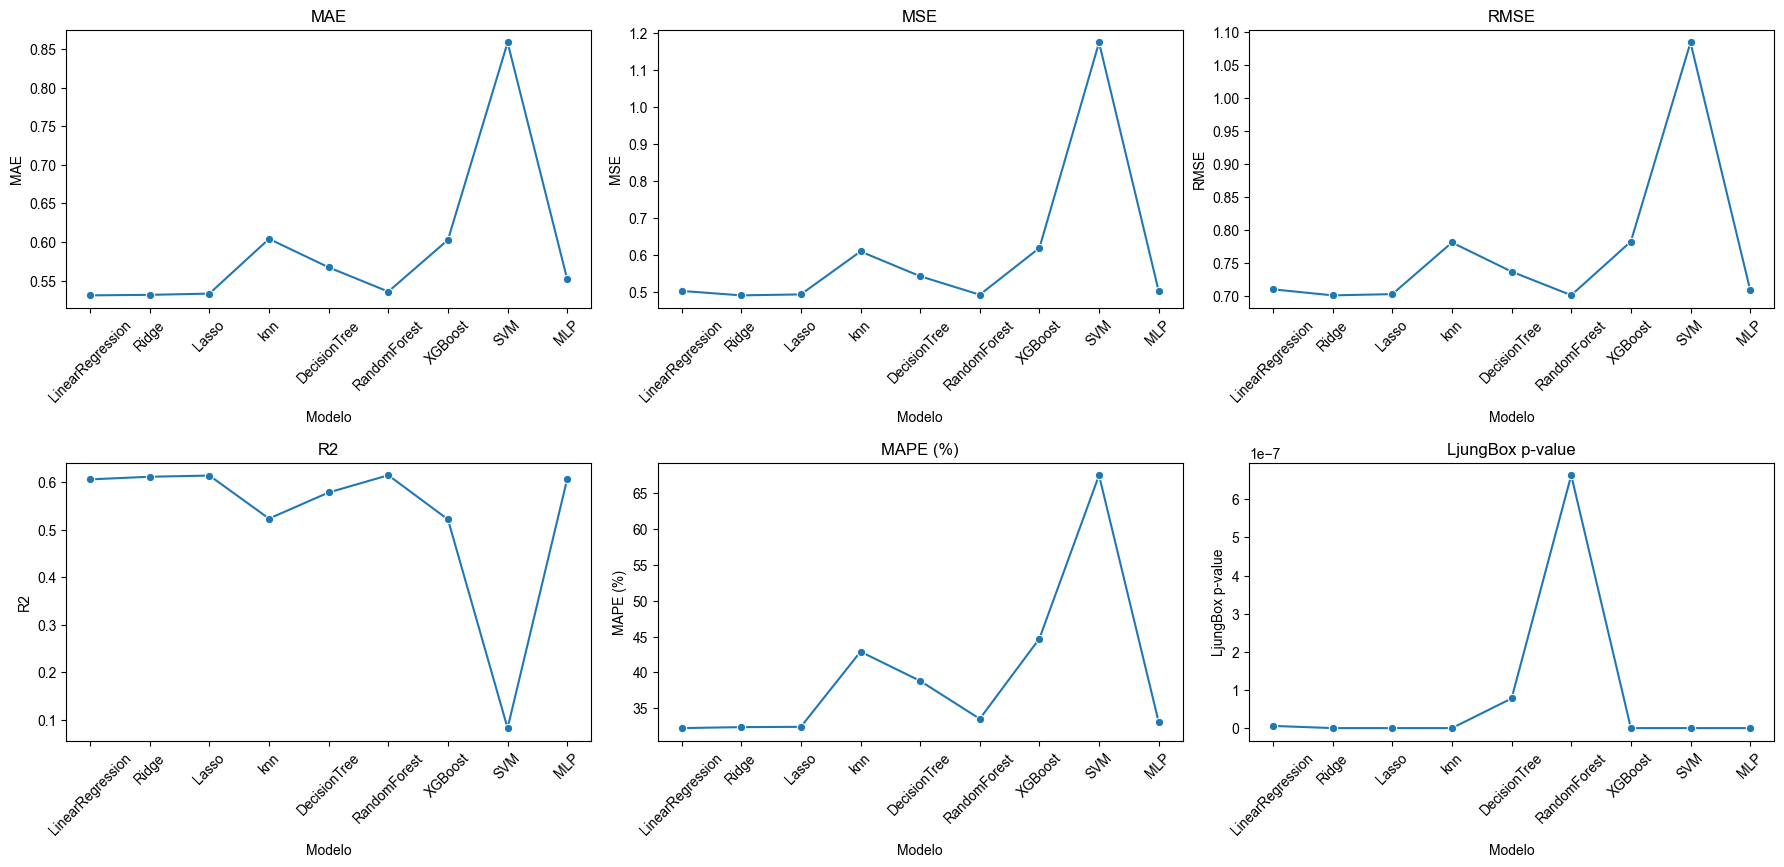

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Reconstrucción del DataFrame
tabla_resultados_test = pd.DataFrame({
    'modelo': [
        'LinearRegression', 'Ridge', 'Lasso', 'knn', 'DecisionTree',
        'RandomForest', 'XGBoost', 'SVM', 'MLP'
    ],
    'ventana_dias': [21]*9,
    'MAE': [0.530762, 0.531421, 0.533032, 0.604018, 0.567094, 0.535614, 0.602743, 0.858822, 0.551587],
    'MSE': [0.503096, 0.491149, 0.493721, 0.609743, 0.542879, 0.492825, 0.619195, 1.174568, 0.502724],
    'RMSE': [0.709926, 0.700820, 0.702653, 0.780861, 0.736742, 0.701056, 0.782301, 1.083757, 0.709031],
    'R2': [0.606147, 0.611686, 0.614176, 0.523509, 0.578538, 0.614876, 0.521749, 0.082121, 0.607140],
    'MAPE (%)': [32.247794, 32.383334, 32.424104, 42.895575, 38.822034, 33.539855, 44.717257, 67.470127, 33.088098],
    'LjungBox p-value': [
        5.748761e-09, 7.543636e-13, 9.837321e-13, 3.703323e-44, 7.783506e-08,
        6.632141e-07, 2.262960e-102, 0.0, 5.846036e-54
    ]
})

# 2. Crear el layout de 3x3 subplots
metricas = ['MAE', 'MSE', 'RMSE', 'R2', 'MAPE (%)', 'LjungBox p-value']
fig, axes = plt.subplots(3, 3, figsize=(18, 12))  # 3 filas, 3 columnas
axes = axes.flatten()  # Aplanar para recorrer fácil

# 3. Graficar
sns.set(style="whitegrid")
for idx, metrica in enumerate(metricas):
    ax = axes[idx]
    sns.lineplot(
        x='modelo',
        y=metrica,
        data=tabla_resultados_test,
        marker='o',
        ax=ax
    )
    ax.set_title(f'{metrica}')
    ax.set_xlabel('Modelo')
    ax.set_ylabel(metrica)
    ax.tick_params(axis='x', rotation=45)

# 4. Apagar los ejes vacíos si sobran
for j in range(len(metricas), 9):
    fig.delaxes(axes[j])

# 5. Ajustar layout final
plt.tight_layout()
plt.show()

Los resultados confirman que los modelos Ridge y MLP son los de mejor desempeño general. Ambos presentan los valores más bajos de RMSE, MAE y MSE, junto con un R² cercano a 0.61, indicando una buena capacidad explicativa. Además, mantienen un MAPE aceptablemente bajo, alrededor del 32%. Por otro lado, el modelo SVM se descarta debido a su elevado error y baja capacidad predictiva. En resumen, Ridge destaca como el mejor modelo, combinando simplicidad, robustez y un rendimiento superior en comparación con el resto.

#### Modelo RNN - regresion

In [77]:
from sklearn.base import BaseEstimator, RegressorMixin
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam

class RNNRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, units=50, activation='tanh', optimizer='adam', epochs=3, batch_size=64, verbose=0):
        self.units = units
        self.activation = activation
        self.optimizer = optimizer
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.model_ = None  # El modelo Keras

    def build_model(self, input_shape):
        model = Sequential()
        model.add(SimpleRNN(self.units, activation=self.activation, input_shape=input_shape))
        model.add(Dense(1))
        model.compile(optimizer=self.optimizer, loss='mse')
        return model

    def fit(self, X, y):
        X = X.values if hasattr(X, 'values') else X  # Asegura que sea np.array
        y = y.values if hasattr(y, 'values') else y
        X = X.reshape((X.shape[0], 1, X.shape[1]))  # (samples, timesteps, features)
        self.model_ = self.build_model((X.shape[1], X.shape[2]))
        self.model_.fit(X, y, epochs=self.epochs, batch_size=self.batch_size, verbose=self.verbose)
        return self

    def predict(self, X):
        X = X.values if hasattr(X, 'values') else X
        X = X.reshape((X.shape[0], 1, X.shape[1]))
        return self.model_.predict(X).flatten()


In [78]:
param_grid = {
    'units': [32],
    'activation': ['relu'],
    'optimizer': ['adam'],
    'epochs': [10],
    'batch_size': [32],
    'verbose': [0]
}

resultadosrnn = validacion_temporal_grid(
    df_train=df,
    features=features,
    target=target,
    modelo_cls=RNNRegressor,
    modelo_nombre='RNN',
    param_grid=param_grid,
    ventanas_dias=[7, 14,21],
    horas_por_dia=24
)


/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


/opt/miniconda3/envs/ml_venv/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


SystemError: /var/folders/nz/j6p8yfhx1mv_0grj5xl4650h0000gp/T/abs_02ejcby2s5/croot/python-split_1733933795450/work/Objects/listobject.c:324: bad argument to internal function

In [200]:
print(resultadosrnn.sort_values('rmse_validacion').head(5))

NameError: name 'resultadosrnn' is not defined

In [ ]:
modelos_dict9 = {
    'RNN': RNNRegressor
}

evaluar_mejores_modelos_en_test(
    resultados_validacion=resultadosrnn,
    df_train=df_train,
    df_test=df_test,
    features=features,
    target='target_variable',
    modelos_dict=modelos_dict9,
    horas_por_dia=24
)

pd.DataFrame(tabla_resultados_test)

#### Modelo LSTM - regresion

In [ ]:
from tensorflow.keras.layers import LSTM

class LSTMRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, units=50, activation='tanh', optimizer='adam', epochs=10, batch_size=32, verbose=0):
        self.units = units
        self.activation = activation
        self.optimizer = optimizer
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.model_ = None

    def build_model(self, input_shape):
        model = Sequential()
        model.add(LSTM(self.units, activation=self.activation, input_shape=input_shape))
        model.add(Dense(1))
        model.compile(optimizer=self.optimizer, loss='mse')
        return model

    def fit(self, X, y):
        X = X.values if hasattr(X, 'values') else X
        y = y.values if hasattr(y, 'values') else y
        X = X.reshape((X.shape[0], 1, X.shape[1]))
        self.model_ = self.build_model((X.shape[1], X.shape[2]))
        self.model_.fit(X, y, epochs=self.epochs, batch_size=self.batch_size, verbose=self.verbose)
        return self

    def predict(self, X):
        X = X.values if hasattr(X, 'values') else X
        X = X.reshape((X.shape[0], 1, X.shape[1]))
        return self.model_.predict(X).flatten()


In [ ]:
param_grid = {
    'units': [32],
    'activation': ['tanh', 'relu'],
    'optimizer': ['adam'],
    'epochs': [5],
    'batch_size': [64],
    'verbose': [0]
}

resultados = validacion_temporal_grid(
    df_train=df,
    features=features,
    target=target,
    modelo_cls=LSTMRegressor, 
    modelo_nombre='LSTM',      
    param_grid=param_grid,
    ventanas_dias=[7, 14,21],
    horas_por_dia=24
)

In [ ]:
modelos_dict10 = {
    'RNN': LSTMRegressor
}

evaluar_mejores_modelos_en_test(
    resultados_validacion=resultadosrnn,
    df_train=df_train,
    df_test=df_test,
    features=features,
    target=target,
    modelos_dict=modelos_dict10,
    horas_por_dia=24
)

pd.DataFrame(tabla_resultados_test)